# Optimal control 

In [1]:
#import tensorflow.compat.v1 as tf
#tf.disable_v2_behavior()

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
if not tf.executing_eagerly():
    tf.compat.v1.enable_eager_execution() # Enable eager execution if it's not already enabled
print(tf.executing_eagerly())  # Confirm that eager execution is now enabled

True


In [3]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.losses import MeanSquaredError

In [4]:
birth = 0.000053 
death =  0.000033 

alpha = 0.00135
sigma = 0.06352
beta1 = 0.2812
beta2 = 0.15838
beta3 = 0.0388
delta1 = 0.28505
delta2 = 0.28269
delta3 = 0.14206
gamma = 0.30954
p1 = 0.01845
p2 = 0.1431
mu = 0.0042
sigma1 = 0.09275
sigma2 = 0.03887
sigma3 = 0.07517
sigma4 = 0.06302
sigma5 = 0.07878
sigma6 = 0.06123
sigma7 = 0.0611
sigma8 = 0.06199


N = 6629870
S0 = 3674149/N
V0 = 2845438/N
E0 = 67789/N
I10 = 12113/N
I20 = 498/N
I30 = 96/N
R0 = 28911/N
D0 = 876/N


In [5]:
k0 =  0.006
k1 = -0.1341

def p1fn(alpha):
    return k0 + k1 * alpha

In [6]:
t_max = 60
points = 60

X = np.random.randint(0, N, size = (points-1, 9)) 
Y = np.zeros((points-1, 1))

dt = t_max/(points)
sqrt_dt = np.sqrt(dt)

In [7]:
c1 = 100
c2 = 20
c3 = 50
c4 = 200
c5 = 1000
c6 = 1/2*300

In [8]:
act_u = np.array([0.0126,
0.0132,
0.0141,
0.0151,
0.0158,
0.0166,
0.0174,
0.0179,
0.0187,
0.0195,
0.0201,
0.0206,
0.0217,
0.0227,
0.0236,
0.0248,
0.0259,
0.0266,
0.0268,
0.0273,
0.0271,
0.0268,
0.0264,
0.0258,
0.0252,
0.0244,
0.024,
0.0211,
0.0211,
0.0207,
0.0203,
0.0195,
0.019,
0.0179,
0.0194,
0.0182,
0.0173,
0.0164,
0.0158,
0.0154,
0.0148,
0.0141,
0.0135,
0.0127,
0.0116,
0.0111,
0.0106,
0.0108,
0.0101,
0.0097,
0.0093,
0.0091,
0.0086,
0.0087,
0.0074,
0.007,
0.0064,
0.0057,
0.005,
0.0048,]) 

In [9]:
u_opt = np.array([
   0.0278,
0.0278,
0.0278,
0.0278,
0.0277,
0.0277,
0.0277,
0.0277,
0.0276,
0.0275,
0.0275,
0.0274,
0.0273,
0.0271,
0.027,
0.0268,
0.0266,
0.0263,
0.0261,
0.0258,
0.0254,
0.0251,
0.0247,
0.0243,
0.0239,
0.0234,
0.0228,
0.0223,
0.0217,
0.0211,
0.0204,
0.0198,
0.0191,
0.0185,
0.0177,
0.017,
0.0163,
0.0156,
0.0149,
0.0141,
0.0134,
0.0127,
0.012,
0.0113,
0.0105,
0.0097,
0.0089,
0.0081,
0.0073,
0.0066,
0.006,
0.0054,
0.005,
0.0047,
0.0045,
0.0044,
0.0043,
0.0043,
0.0043,
0.0042])

In [10]:
sigma_large = 2
u_opt_sigma_large = np.array([ 
    0.0242, 0.0231, 0.0225, 0.0222, 0.0215, 0.0213, 
    0.0211, 0.0208, 0.0207, 0.0209, 0.0208, 0.0206, 
    0.0206, 0.0205, 0.0206, 0.0203, 0.0205, 0.0205, 
    0.0202, 0.0201, 0.0203, 0.0201, 0.0204, 0.0200, 
    0.0201, 0.0198, 0.0201, 0.0201, 0.0199, 0.0198, 
    0.0198, 0.0199, 0.0198, 0.0198, 0.0202, 0.0195, 
    0.0199, 0.0200, 0.0196, 0.0199, 0.0197, 0.0195, 
    0.0193, 0.0195, 0.0194, 0.0192, 0.0191, 0.0188,
    0.0188, 0.0184, 0.0180, 0.0176, 0.0170, 0.0163, 
    0.0151, 0.0137, 0.0107, 0.0069, 0.0059, 0.0052])

In [11]:
sigma_small = 0.5
u_opt_sigma_small = np.array([  
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0247,
0.0247,
0.0247,
0.0247,
0.0246,
0.0246,
0.0245,
0.0245,
0.0244,
0.0243,
0.0242,
0.0241,
0.024,
0.0238,
0.0237,
0.0234,
0.0232,
0.023,
0.0227,
0.0224,
0.022,
0.0216,
0.0211,
0.0207,
0.0201,
0.0195,
0.0189,
0.0182,
0.0176,
0.0169,
0.016,
0.0152,
0.0143,
0.0133,
0.0123,
0.0113,
0.0103,
0.0093,
0.0084,
0.0076,
0.0069,
0.0064,
0.006,
0.0057,
0.0054,
0.0053,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052])

In [12]:
sigma_tiny = 0.1
u_opt_sigma_tiny = np.array([ 
    0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0248,
0.0247,
0.0245,
0.0241,
0.0234,
0.0225,
0.0212,
0.0196,
0.0179,
0.016,
0.0141,
0.0123,
0.0108,
0.0094,
0.0083,
0.0074,
0.0067,
0.0062,
0.0058,
0.0056,
0.0054,
0.0053,
0.0053,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052,
0.0052 ]) 

In [13]:
### Strategy 0: No vaccination

In [14]:
np.random.seed(123) #no vacc

alpha_ori = 0

S_ori = np.zeros(int(t_max/dt) + 1)
V_ori = np.zeros(int(t_max/dt) + 1)
E_ori = np.zeros(int(t_max/dt) + 1)
I1_ori = np.zeros(int(t_max/dt) + 1)
I2_ori = np.zeros(int(t_max/dt) + 1)
I3_ori = np.zeros(int(t_max/dt) + 1)
R_ori = np.zeros(int(t_max/dt) + 1)
D_ori = np.zeros(int(t_max/dt) + 1)

S_ori[0] = S0 #* N
V_ori[0] = V0 #* N
E_ori[0] = E0 #* N
I1_ori[0] = I10 #* N
I2_ori[0] = I20 #* N
I3_ori[0] = I30 #* N
R_ori[0] = R0 #* N
D_ori[0] = D0 #* N

for i in range(1, len(S_ori)):

    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()

    dS_ori = (birth - ( beta1 * I1_ori[i-1] + beta2 * I2_ori[i-1] + beta3 * I3_ori[i-1]) * S_ori[i-1]- alpha_ori * S_ori[i-1]-death * S_ori[i-1]) 
    dV_ori = (alpha_ori * S_ori[i-1] - sigma * (beta1 * I1_ori[i-1] + beta2 * I2_ori[i-1] + beta3 * I3_ori[i-1]) * V_ori[i-1] - death*V_ori[i-1])  
    dE_ori = ((beta1 * I1_ori[i-1] + beta2 * I2_ori[i-1] + beta3 * I3_ori[i-1]) * S_ori[i-1]  \
          + sigma * (beta1 * I1_ori[i-1] + beta2 * I2_ori[i-1] + beta3 * I3_ori[i-1]) * V_ori[i-1]  - gamma * E_ori[i-1]-death*E_ori[i-1]) 
    dI1_ori = (gamma * E_ori[i-1] - (delta1 + p1) * I1_ori[i-1]-death*I1_ori[i-1]) 
    dI2_ori = (p1 * I1_ori[i-1] - (delta2 + p2) * I2_ori[i-1]-death*I2_ori[i-1]) 
    dI3_ori = (p2 * I2_ori[i-1] - (delta3 + mu) * I3_ori[i-1]-death*I3_ori[i-1]) 
    dR_ori = (delta1 * I1_ori[i-1]+ delta2 * I2_ori[i-1] + delta3 * I3_ori[i-1]-death*R_ori[i-1]) 
    dD_ori = (mu * I3_ori[i-1])

    S_ori[i] = S_ori[i-1] + dS_ori * dt + sigma1 * S_ori[i-1] * sqrt_dt * dW1
    V_ori[i] = V_ori[i-1] + dV_ori * dt + sigma2 * V_ori[i-1] * sqrt_dt * dW2
    E_ori[i] = E_ori[i-1] + dE_ori * dt + sigma3 * E_ori[i-1] * sqrt_dt * dW3
    I1_ori[i] = I1_ori[i-1] + dI1_ori * dt + sigma4 * I1_ori[i-1] * sqrt_dt * dW4
    I2_ori[i] = I2_ori[i-1] + dI2_ori * dt + sigma5 * I2_ori[i-1] * sqrt_dt * dW5
    I3_ori[i] = I3_ori[i-1] + dI3_ori * dt + sigma6 * I3_ori[i-1] * sqrt_dt * dW6
    R_ori[i] = R_ori[i-1] + dR_ori * dt + sigma7 * R_ori[i-1] * sqrt_dt * dW7
    D_ori[i] = D_ori[i-1] + dD_ori * dt + sigma8 * D_ori[i-1] * sqrt_dt * dW8

    N_ori_t = 1/(S_ori[i] + V_ori[i] + E_ori[i] + I1_ori[i] + I2_ori[i] + I3_ori[i] + R_ori[i] + D_ori[i])
    
    if i % 30 == 0:  # print every 1000 steps
        print(f"Step {i}: S = {S_ori[i]/N_ori_t}, V = {V_ori[i]/N_ori_t},  E = {E_ori[i]/N_ori_t},  I1 = {I1_ori[i]/N_ori_t},  I2 = {I2_ori[i]/N_ori_t},  I3 = {I3_ori[i]/N_ori_t},  R = {R_ori[i]/N_ori_t}, D = {D_ori[i]/N_ori_t}")


Step 30: S = 0.9400045590128712, V = 0.40662097701096617,  E = 0.001211033959283161,  I1 = 0.0013309948785594013,  I2 = 6.784641224531884e-05,  I3 = 9.02245300301692e-05,  R = 0.04963289569351765, D = 0.00015352887958375904
Step 60: S = 1.0927920506504578, V = 0.4514823846628878,  E = 0.0001695997578002319,  I1 = 0.00018940076355317712,  I2 = 9.301800539971638e-06,  I3 = 2.356988387585839e-05,  R = 0.025800190400025153, D = 0.00012185830614498569


In [15]:
# total cost over the period
N_path_ori = S_ori + V_ori + E_ori + I1_ori + I2_ori + I3_ori + R_ori + D_ori

hosp_ori_cost = c3 * sum(I1_ori*N_path_ori) + c4 * sum(I2_ori*N_path_ori) + c5 * sum(I3_ori*N_path_ori)
vacc_ori_cost = c1 * sum(np.repeat(alpha_ori**2, points))
qua_ori_cost = c2 * sum(E_ori*N_path_ori)
econ_ori_cost = c6 * sum(E_ori*N_path_ori + I1_ori*N_path_ori+I2_ori*N_path_ori+I3_ori*N_path_ori + D_ori*N_path_ori)

total_ori_cost = hosp_ori_cost+vacc_ori_cost+qua_ori_cost+econ_ori_cost

data_ori_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'No Vacc': [hosp_ori_cost, vacc_ori_cost+qua_ori_cost, econ_ori_cost],
                  'Percentage': [format(hosp_ori_cost/total_ori_cost * 100, ".2f") + "%",
                                 format((vacc_ori_cost+qua_ori_cost)/total_ori_cost * 100, ".2f") + "%",
                                 format(econ_ori_cost/total_ori_cost * 100, ".2f") + "%"] }
df_ori = pd.DataFrame(data_ori_table)
df_ori.set_index('Type', inplace=True)
print(df_ori)
print('Totoal Cost',total_ori_cost)

               No Vacc Percentage
Type                             
Hosp Cost    12.170532     23.08%
Policy Cost   2.309103      4.38%
Econ Cost    38.260726     72.55%
Totoal Cost 52.74036089064565


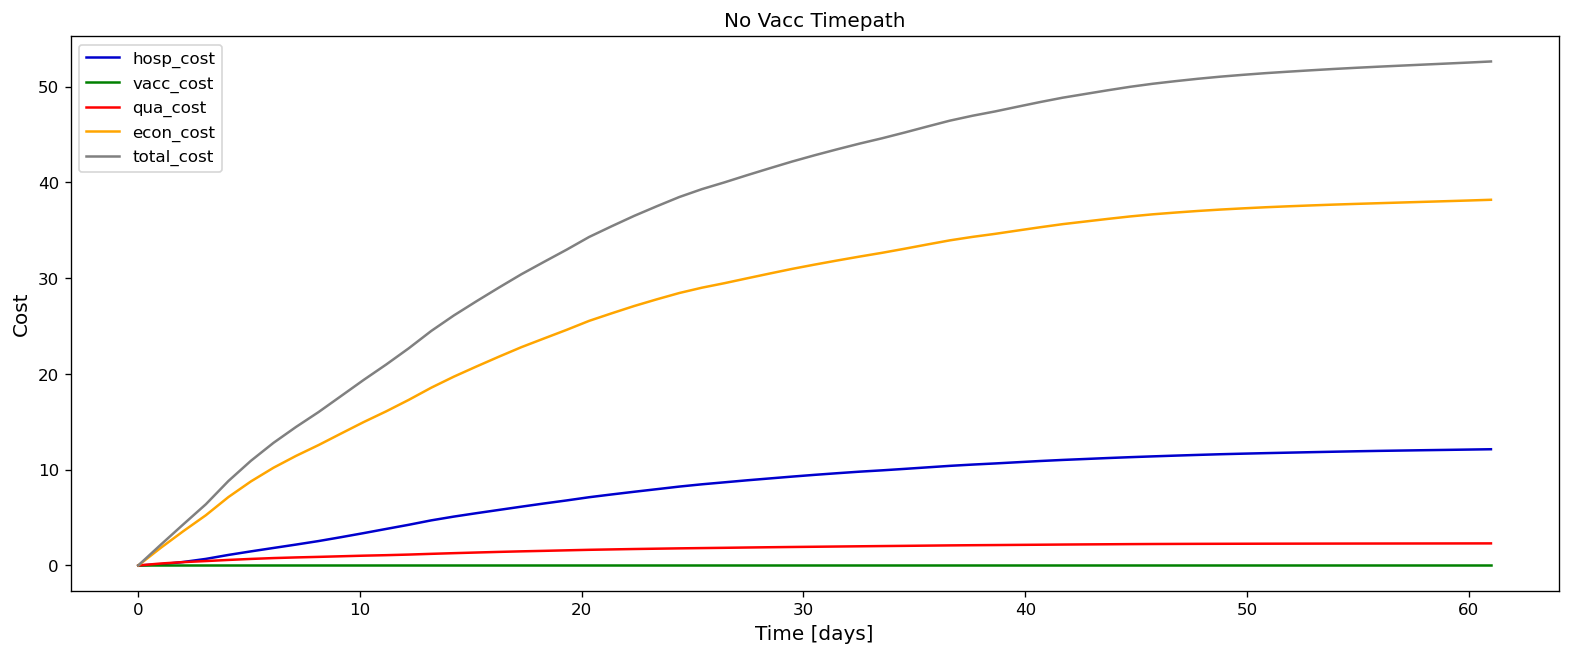

In [16]:
# Cost analysis: no vaccination 
hosp_ori_cost_partial = np.repeat(0.00, len(S_ori))
vacc_ori_cost_partial = np.repeat(0.00, len(S_ori))
qua_ori_cost_partial = np.repeat(0.00, len(S_ori))
econ_ori_cost_partial = np.repeat(0.00, len(S_ori))
total_ori_cost_partial = np.repeat(0.00, len(S_ori))
vacc_ori_cost_step = np.repeat(0**2, points)

for i in range(1, len(S_ori)):
    hosp_ori_cost_partial[i] = c3 * sum(I1_ori[0:i]*N_path_ori[0:i]) + c4 * sum(I2_ori[0:i]*N_path_ori[0:i]) + c5 * sum(I3_ori[0:i]*N_path_ori[0:i])
    vacc_ori_cost_partial[i] = c1 * sum(vacc_ori_cost_step[0:i]**2)
    qua_ori_cost_partial[i] = c2 * sum(E_ori[0:i]*N_path_ori[0:i])
    econ_ori_cost_partial[i] = c6 * sum(E_ori[0:i]*N_path_ori[0:i]+I1_ori[0:i]*N_path_ori[0:i]+I2_ori[0:i]*N_path_ori[0:i]+I3_ori[0:i]*N_path_ori[0:i]+D_ori[0:i]*N_path_ori[0:i])
    total_ori_cost_partial[i] = hosp_ori_cost_partial[i]+vacc_ori_cost_partial[i]+qua_ori_cost_partial[i]+econ_ori_cost_partial[i]

t = np.linspace(0, len(S_ori), len(S_ori))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_ori_cost_partial, lw = 1.5, color = 'mediumblue', label = 'hosp_cost')
ax0.plot(t, vacc_ori_cost_partial, lw = 1.5, color = 'green', label = 'vacc_cost')
ax0.plot(t, qua_ori_cost_partial, lw = 1.5, color = 'red', label = 'qua_cost')
ax0.plot(t, econ_ori_cost_partial, lw = 1.5, color = 'orange', label = 'econ_cost')
ax0.plot(t, total_ori_cost_partial, lw = 1.5, color = 'grey', label = 'total_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('No Vacc Timepath', fontsize = 12)
ax0.legend()

### Strategy 1: Constant Vaccination Rate

In [17]:
np.random.seed(123) #constant vacc

alpha_constant = 0.0126 
p1 = 0.01353 

S_con = np.zeros(int(t_max/dt) + 1)
V_con = np.zeros(int(t_max/dt) + 1)
E_con = np.zeros(int(t_max/dt) + 1)
I1_con = np.zeros(int(t_max/dt) + 1)
I2_con = np.zeros(int(t_max/dt) + 1)
I3_con = np.zeros(int(t_max/dt) + 1)
R_con = np.zeros(int(t_max/dt) + 1)
D_con = np.zeros(int(t_max/dt) + 1)

S_con[0] = S0 #* N
V_con[0] = V0 #* N
E_con[0] = E0 #* N
I1_con[0] = I10 #* N
I2_con[0] = I20 #* N
I3_con[0] = I30 #* N
R_con[0] = R0 #* N
D_con[0] = D0 #* N


for i in range(1, len(S_con)):

    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()

    dS_con = (birth - ( beta1 * I1_con[i-1] + beta2 * I2_con[i-1] + beta3 * I3_con[i-1]) * S_con[i-1]- alpha_constant * S_con[i-1]-death * S_con[i-1]) 
    dV_con = (alpha_constant * S_con[i-1] - sigma * (beta1 * I1_con[i-1] + beta2 * I2_con[i-1] + beta3 * I3_con[i-1]) * V_con[i-1] - death*V_con[i-1])  
    dE_con = ((beta1 * I1_con[i-1] + beta2 * I2_con[i-1] + beta3 * I3_con[i-1]) * S_con[i-1]  \
          + sigma * (beta1 * I1_con[i-1] + beta2 * I2_con[i-1] + beta3 * I3_con[i-1]) * V_con[i-1]  - gamma * E_con[i-1]-death*E_con[i-1]) 
    dI1_con = (gamma * E_con[i-1] - (delta1 + p1) * I1_con[i-1]-death*I1_con[i-1]) 
    dI2_con = (p1 * I1_con[i-1] - (delta2 + p2) * I2_con[i-1]-death*I2_con[i-1]) 
    dI3_con = (p2 * I2_con[i-1] - (delta3 + mu) * I3_con[i-1]-death*I3_con[i-1]) 
    dR_con = (delta1 * I1_con[i-1]+ delta2 * I2_con[i-1] + delta3 * I3_con[i-1]-death*R_con[i-1]) 
    dD_con = (mu * I3_con[i-1])

    S_con[i] = S_con[i-1] + dS_con * dt + sigma1 * S_con[i-1] * sqrt_dt * dW1
    V_con[i] = V_con[i-1] + dV_con * dt + sigma2 * V_con[i-1] * sqrt_dt * dW2
    E_con[i] = E_con[i-1] + dE_con * dt + sigma3 * E_con[i-1] * sqrt_dt * dW3
    I1_con[i] = I1_con[i-1] + dI1_con * dt + sigma4 * I1_con[i-1] * sqrt_dt * dW4
    I2_con[i] = I2_con[i-1] + dI2_con * dt + sigma5 * I2_con[i-1] * sqrt_dt * dW5
    I3_con[i] = I3_con[i-1] + dI3_con * dt + sigma6 * I3_con[i-1] * sqrt_dt * dW6
    R_con[i] = R_con[i-1] + dR_con * dt + sigma7 * R_con[i-1] * sqrt_dt * dW7
    D_con[i] = D_con[i-1] + dD_con * dt + sigma8 * D_con[i-1] * sqrt_dt * dW8

    N_con_t = 1/(S_con[i] + V_con[i] + E_con[i] + I1_con[i] + I2_con[i] + I3_con[i] + R_con[i] + D_con[i])
    
    if i % 30 == 0:  # print every 1000 steps
        print(f"Step {i}: S = {S_con[i]/N_con_t}, V = {V_con[i]/N_con_t},  E = {E_con[i]/N_con_t},  I1 = {I1_con[i]/N_con_t},  I2 = {I2_con[i]/N_con_t},  I3 = {I3_con[i]/N_con_t}, R = {R_con[i]/N_con_t}, D = {D_con[i]/N_con_t}")


Step 30: S = 0.6014037953313998, V = 0.5658743604428346,  E = 0.0005746918870995041,  I1 = 0.0007510010828226199,  I2 = 3.057685525931506e-05,  I3 = 5.069634712531695e-05, R = 0.04360215763030055, D = 0.0001387695638458827
Step 60: S = 0.4612762670766489, V = 0.7739168303795786,  E = 1.305253628583247e-05,  I1 = 2.0533823058657848e-05,  I2 = 8.923674969251718e-07,  I3 = 4.73354027628817e-06, R = 0.01959498457364185, D = 0.00010278615614519439


In [18]:
# total cost table
N_path_con = S_con + V_con + E_con + I1_con + I2_con + I3_con + R_con + D_con
hosp_constant_cost = c3 * sum(I1_con*N_path_con) + c4 * sum(I2_con*N_path_con) + c5 * sum(I3_con*N_path_con)
vacc_constant_cost = c1 * sum(np.repeat(alpha_constant**2, points))
qua_constant_cost = c2 * sum(E_con*N_path_con)
econ_constant_cost = c6 * sum(E_con*N_path_con+I1_con*N_path_con+I2_con*N_path_con+I3_con*N_path_con+D_con*N_path_con)

total_constant_cost = hosp_constant_cost+vacc_constant_cost+qua_constant_cost+econ_constant_cost

data_constant_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'Constant vacc': [hosp_constant_cost, vacc_constant_cost+qua_constant_cost, econ_constant_cost],
                  'Percentage': [format(hosp_constant_cost/total_constant_cost * 100, ".2f") + "%",
                                 format((vacc_constant_cost+qua_constant_cost)/total_constant_cost * 100, ".2f") + "%",
                                 format(econ_constant_cost/total_constant_cost * 100, ".2f") + "%"] }
df_constant = pd.DataFrame(data_constant_table)
df_constant.set_index('Type', inplace=True)
print(df_constant)
print('Totoal Cost',total_constant_cost)

             Constant vacc Percentage
Type                                 
Hosp Cost         8.839819     20.81%
Policy Cost       2.790411      6.57%
Econ Cost        30.847319     72.62%
Totoal Cost 42.477549591578565


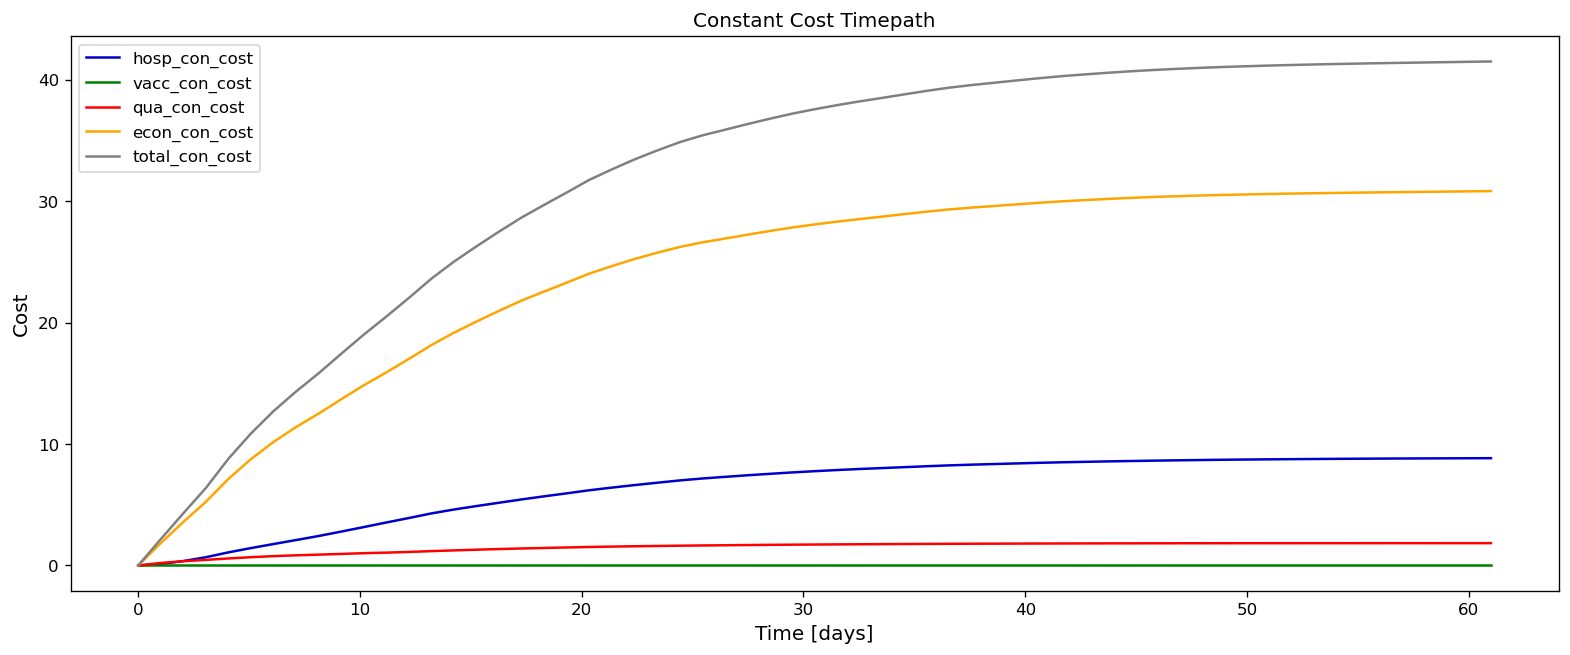

In [19]:
# Cost timepath
hosp_con_cost_partial = np.repeat(0.00, len(S_con))
vacc_con_cost_partial = np.repeat(0.00, len(S_con))
qua_con_cost_partial = np.repeat(0.00, len(S_con))
econ_con_cost_partial = np.repeat(0.00, len(S_con))
total_con_cost_partial = np.repeat(0.00, len(S_con))

vacc_constant_cost_partial = np.repeat(alpha_constant**2, points)

for i in range(1, len(S_con)):
    hosp_con_cost_partial[i] = c3 * sum(I1_con[0:i]*N_path_con[0:i]) + c4 * sum(I2_con[0:i]*N_path_con[0:i]) + c5 * sum(I3_con[0:i]*N_path_con[0:i])
    vacc_con_cost_partial[i] = c1 * sum(vacc_constant_cost_partial[0:i]**2)
    qua_con_cost_partial[i] = c2 * sum(E_con[0:i]*N_path_con[0:i])
    econ_con_cost_partial[i] = c6 * sum(E_con[0:i]*N_path_con[0:i]+I1_con[0:i]*N_path_con[0:i]+I2_con[0:i]*N_path_con[0:i]+I3_con[0:i]*N_path_con[0:i]+D_con[0:i]*N_path_con[0:i])
    total_con_cost_partial[i] = hosp_con_cost_partial[i]+vacc_con_cost_partial[i]+qua_con_cost_partial[i]+econ_con_cost_partial[i]

t = np.linspace(0, len(S_con), len(S_con))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_con_cost_partial, lw = 1.5,  color = 'mediumblue', label = 'hosp_con_cost')
ax0.plot(t, vacc_con_cost_partial, lw = 1.5,  color = 'green', label = 'vacc_con_cost')
ax0.plot(t, qua_con_cost_partial, lw = 1.5,  color = 'red', label = 'qua_con_cost')
ax0.plot(t, econ_con_cost_partial, lw = 1.5,  color = 'orange', label = 'econ_con_cost')
ax0.plot(t, total_con_cost_partial, lw = 1.5,  color = 'grey', label = 'total_con_cost')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Constant Cost Timepath', fontsize = 12)
ax0.legend()

#### Strategy 2: Actual Vaccination Rate

In [20]:
np.random.seed(123) #act vacc

repeat_times = points/len(act_u)
repeated_act_u = np.repeat(act_u, repeat_times , axis=0)

S_act = np.zeros(int(t_max/dt) + 1)
V_act = np.zeros(int(t_max/dt) + 1)
E_act = np.zeros(int(t_max/dt) + 1)
I1_act = np.zeros(int(t_max/dt) + 1)
I2_act = np.zeros(int(t_max/dt) + 1)
I3_act = np.zeros(int(t_max/dt) + 1)
R_act = np.zeros(int(t_max/dt) + 1)
D_act = np.zeros(int(t_max/dt) + 1)

S_act[0] = S0 #* N_pob
V_act[0] = V0 #* N_pob
E_act[0] = E0 #* N_pob
I1_act[0] = I10 #* N_pob
I2_act[0] = I20 #* N_pob
I3_act[0] = I30 #* N_pob
R_act[0] = R0 #* N_pob
D_act[0] = D0 #* N_pob


In [21]:
for i in range(1, len(S_act)):
 
    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()
 
    dS = (birth - ( beta1 * I1_act[i-1] + beta2 * I2_act[i-1] + beta3 * I3_act[i-1]) * S_act[i-1] - repeated_act_u[i-1] * S_act[i-1] - death* S_act[i-1]) 
    dV = (repeated_act_u[i-1] * S_act[i-1] - sigma * (beta1 * I1_act[i-1] + beta2 * I2_act[i-1] + beta3 * I3_act[i-1]) * V_act[i-1] - death* V_act[i-1])  
    dE = ((beta1 * I1_act[i-1] + beta2 * I2_act[i-1] + beta3 * I3_act[i-1]) * S_act[i-1]  \
          + sigma * (beta1 * I1_act[i-1] + beta2 * I2_act[i-1] + beta3 * I3_act[i-1]) * V_act[i-1] - gamma * E_act[i-1]- death* E_act[i-1]) 
    dI1 = (gamma * E_act[i-1] - (delta1 + p1fn(repeated_act_u[i-1])) * I1_act[i-1]- death* I1_act[i-1]) 
    dI2 = (p1fn(repeated_act_u[i-1]) * I1_act[i-1] - (delta2 + p2) * I2_act[i-1]- death* I2_act[i-1]) 
    dI3 = (p2 * I2_act[i-1] - (delta3 + mu) * I3_act[i-1]- death* I3_act[i-1]) 
    dR = (delta1 * I1_act[i-1]+ delta2 * I2_act[i-1] + delta3 * I3_act[i-1]- death* R_act[i-1]) 
    dD = (mu * I3_act[i-1])

    S_act[i] = S_act[i-1] + dS * dt + sigma1 * S_act[i-1] * sqrt_dt * dW1 
    V_act[i] = V_act[i-1] + dV * dt + sigma2 * V_act[i-1] * sqrt_dt * dW2
    E_act[i] = E_act[i-1] + dE * dt + sigma3 * E_act[i-1] * sqrt_dt * dW3
    I1_act[i] = I1_act[i-1] + dI1 * dt + sigma4 * I1_act[i-1] * sqrt_dt * dW4
    I2_act[i] = I2_act[i-1] + dI2 * dt + sigma5 * I2_act[i-1] * sqrt_dt * dW5
    I3_act[i] = I3_act[i-1] + dI3 * dt + sigma6 * I3_act[i-1] * sqrt_dt * dW6
    R_act[i] = R_act[i-1] + dR * dt + sigma7 * R_act[i-1] * sqrt_dt * dW7
    D_act[i] = D_act[i-1] + dD * dt + sigma8 * D_act[i-1] * sqrt_dt * dW8
    
    N_act_t = 1/(S_act[i] + V_act[i] + E_act[i] + I1_act[i] + I2_act[i] + I3_act[i] + R_act[i] + D_act[i])

    if i % 30 == 0:  # print every 30 steps
        print(f"Step {i}: S = {S_act[i]/N_act_t}, V = {V_act[i]/N_act_t},  E = {E_act[i]/N_act_t},  I1 = {I1_act[i]/N_act_t},  I2 = {I2_act[i]/N_act_t},  I3 = {I3_act[i]/N_act_t}, R = {R_act[i]/N_act_t}, D = {D_act[i]/N_act_t}, u = {repeated_act_u[i-1]}")


Step 30: S = 0.44351130717878, V = 0.6431671956382764,  E = 0.0004147228129944058,  I1 = 0.0006270742798007593,  I2 = 6.114234381685242e-06,  I3 = 1.0309172893714622e-05, R = 0.04180764612470942, D = 0.00012683261308073078, u = 0.0207
Step 60: S = 0.34420253915505233, V = 0.8201462901154274,  E = 4.651384635044981e-06,  I1 = 8.616264390426968e-06,  I2 = 1.5427445975150033e-07,  I3 = 9.05190309339813e-07, R = 0.018453606516844735, D = 9.286352193594915e-05, u = 0.0048


In [22]:
# cost table
N_path_act = S_act + V_act + E_act + I1_act + I2_act + I3_act + R_act + D_act
hosp_act_cost = c3 * sum(I1_act*N_path_act) + c4 * sum(I2_act*N_path_act) + c5 * sum(I3_act*N_path_act)
vacc_act_cost = c1 * sum(repeated_act_u**2)
qua_act_cost = c2 * sum(E_act*N_path_act)
econ_act_cost = c6 * sum(E_act*N_path_act+I1_act*N_path_act+I2_act*N_path_act+I3_act*N_path_act+D_act*N_path_act)
total_act_cost = hosp_act_cost+vacc_act_cost+qua_act_cost+econ_act_cost

data_act_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'Actual vacc': [hosp_act_cost,vacc_act_cost+qua_act_cost,econ_act_cost],
                  'Percentage': [format(hosp_act_cost/total_act_cost * 100, ".2f") + "%",
                                 format((vacc_act_cost+qua_act_cost)/total_act_cost * 100, ".2f") + "%",
                                 format(econ_act_cost/total_act_cost * 100, ".2f") + "%"] }
df_act = pd.DataFrame(data_act_table)
df_act.set_index('Type', inplace=True)
print(df_act)

             Actual vacc Percentage
Type                               
Hosp Cost       6.155105     15.70%
Policy Cost     3.717584      9.48%
Econ Cost      29.340147     74.82%


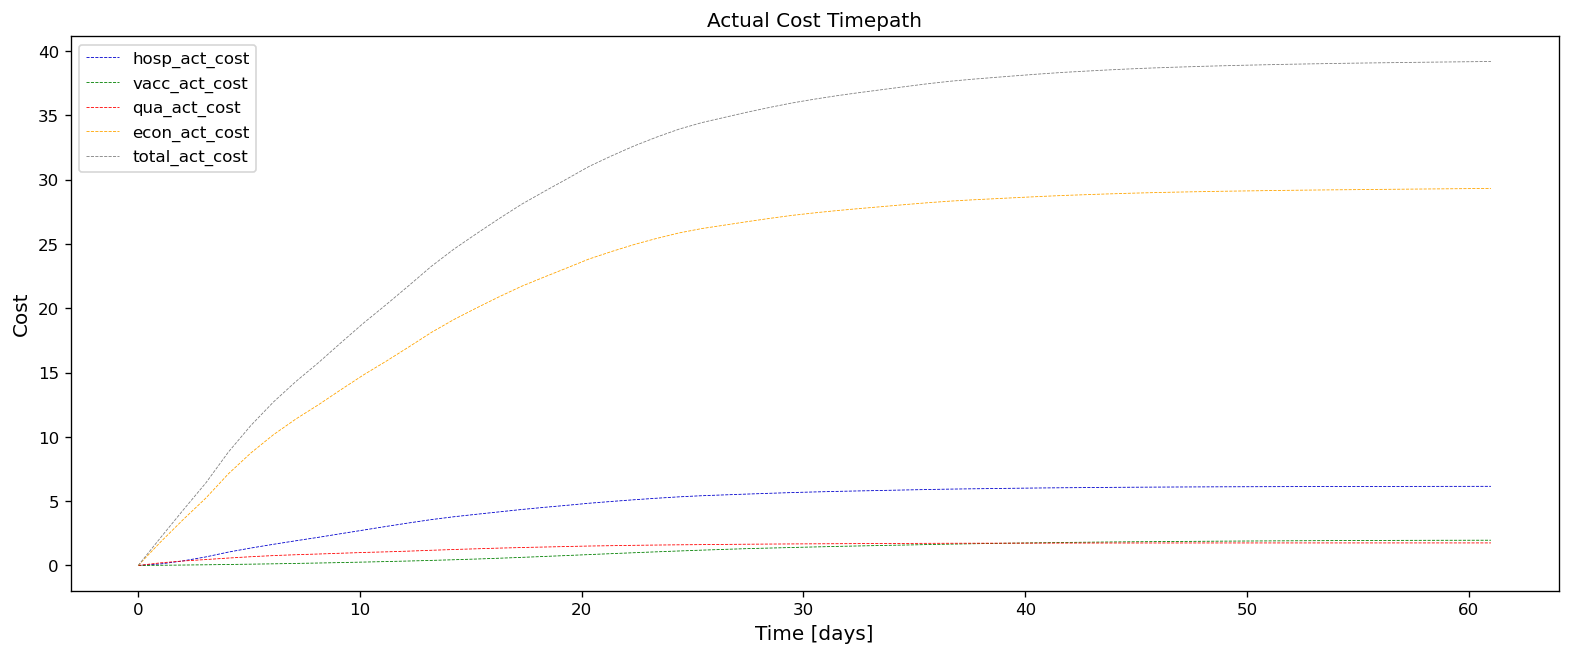

In [23]:
# Cost analysis
hosp_act_cost_partial = np.repeat(0.00, len(S_act))
vacc_act_cost_partial = np.repeat(0.00, len(S_act))
qua_act_cost_partial = np.repeat(0.00, len(S_act))
econ_act_cost_partial = np.repeat(0.00, len(S_act))
total_act_cost_partial = np.repeat(0.00, len(S_act))


for i in range(1, len(S_act)):
    hosp_act_cost_partial[i] = c3 * sum(I1_act[0:i]*N_path_act[0:i]) + c4 * sum(I2_act[0:i]*N_path_act[0:i]) + c5 * sum(I3_act[0:i]*N_path_act[0:i])
    vacc_act_cost_partial[i] = c1 * sum(repeated_act_u[0:i]**2)
    qua_act_cost_partial[i] = c2 * sum(E_act[0:i]*N_path_act[0:i])
    econ_act_cost_partial[i] = c6 * sum(E_act[0:i]*N_path_act[0:i]+I1_act[0:i]*N_path_act[0:i]+I2_act[0:i]*N_path_act[0:i]+I3_act[0:i]*N_path_act[0:i]+D_act[0:i]*N_path_act[0:i])
    total_act_cost_partial[i] = hosp_act_cost_partial[i]+vacc_act_cost_partial[i]+qua_act_cost_partial[i]+econ_act_cost_partial[i]

t = np.linspace(0, len(S_act), len(S_act))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_act_cost_partial, lw = 0.5, ls = '--', color = 'mediumblue', label = 'hosp_act_cost')
ax0.plot(t, vacc_act_cost_partial, lw = 0.5, ls = '--', color = 'green', label = 'vacc_act_cost')
ax0.plot(t, qua_act_cost_partial, lw = 0.5, ls = '--', color = 'red', label = 'qua_act_cost')
ax0.plot(t, econ_act_cost_partial, lw = 0.5, ls = '--', color = 'orange', label = 'econ_act_cost')
ax0.plot(t, total_act_cost_partial, lw = 0.5, ls = '--', color = 'grey', label = 'total_act_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Actual Cost Timepath', fontsize = 12)
ax0.legend()

### Strategy 3-1: Optimal Vaccination Rate (sigma=0.1)

In [24]:
# optimal vaccination rate use past paper's result
repeat_times = points/len(u_opt)
repeated_u = np.repeat(u_opt, repeat_times , axis=0)


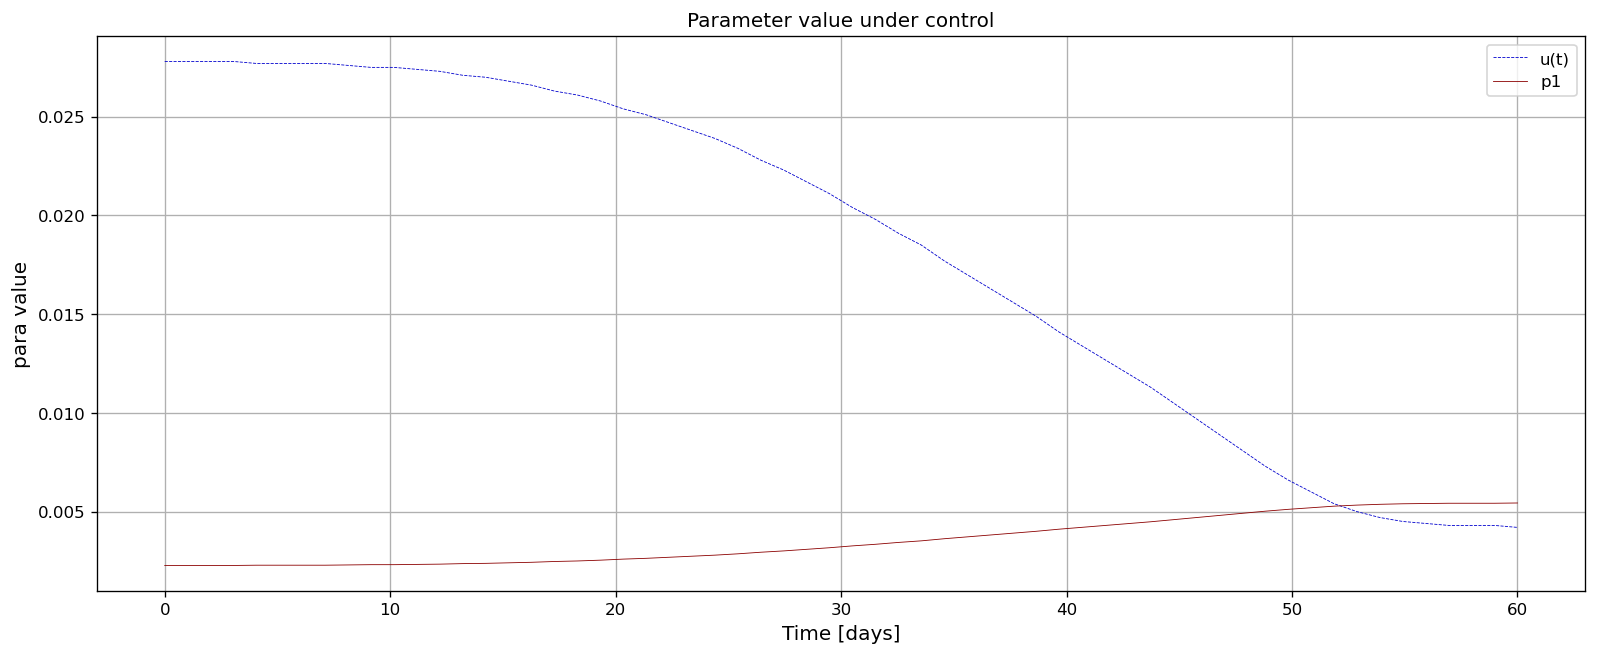

In [25]:
t = np.linspace(0, t_max, len(repeated_u))

fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, repeated_u, lw = 0.5, ls = '--', color = 'mediumblue', label = 'u(t)')
ax0.plot(t, p1fn(repeated_u), lw = 0.5, color = 'darkred', label = 'p1')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('para value', fontsize = 12)
ax0.set_title('Parameter value under control', fontsize = 12)

ax0.legend()
ax0.grid()
plt.show()

In [26]:
np.random.seed(123) #optimal vacc seed

S = np.zeros(int(t_max/dt) + 1)
V = np.zeros(int(t_max/dt) + 1)
E = np.zeros(int(t_max/dt) + 1)
I1 = np.zeros(int(t_max/dt) + 1)
I2 = np.zeros(int(t_max/dt) + 1)
I3 = np.zeros(int(t_max/dt) + 1)
R = np.zeros(int(t_max/dt) + 1)
D = np.zeros(int(t_max/dt) + 1)

S[0] = S0 #* N_pob
V[0] = V0 #* N_pob
E[0] = E0 #* N_pob
I1[0] = I10 #* N_pob
I2[0] = I20 #* N_pob
I3[0] = I30 #* N_pob
R[0] = R0 #* N_pob
D[0] = D0 #* N_pob

for i in range(1, len(S)):
 
    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()
 
    dS = (birth - ( beta1 * I1[i-1] + beta2 * I2[i-1] + beta3 * I3[i-1]) * S[i-1] - repeated_u[i-1] * S[i-1] - death* S[i-1]) 
    dV = (repeated_u[i-1] * S[i-1] - sigma * (beta1 * I1[i-1] + beta2 * I2[i-1] + beta3 * I3[i-1]) * V[i-1] - death* V[i-1])  
    dE = ((beta1 * I1[i-1] + beta2 * I2[i-1] + beta3 * I3[i-1]) * S[i-1]  \
          + sigma * (beta1 * I1[i-1] + beta2 * I2[i-1] + beta3 * I3[i-1]) * V[i-1] - gamma * E[i-1]- death* E[i-1]) 
    dI1 = (gamma * E[i-1] - (delta1 + p1fn(repeated_u[i-1])) * I1[i-1]- death* I1[i-1]) 
    dI2 = (p1fn(repeated_u[i-1]) * I1[i-1] - (delta2 + p2) * I2[i-1]- death* I2[i-1]) 
    dI3 = (p2 * I2[i-1] - (delta3 + mu) * I3[i-1]- death* I3[i-1]) 
    dR = (delta1 * I1[i-1]+ delta2 * I2[i-1] + delta3 * I3[i-1]- death* R[i-1]) 
    dD = (mu * I3[i-1])

    S[i] = S[i-1] + dS * dt + sigma1 * S[i-1] * sqrt_dt * dW1 
    V[i] = V[i-1] + dV * dt + sigma2 * V[i-1] * sqrt_dt * dW2
    E[i] = E[i-1] + dE * dt + sigma3 * E[i-1] * sqrt_dt * dW3
    I1[i] = I1[i-1] + dI1 * dt + sigma4 * I1[i-1] * sqrt_dt * dW4
    I2[i] = I2[i-1] + dI2 * dt + sigma5 * I2[i-1] * sqrt_dt * dW5
    I3[i] = I3[i-1] + dI3 * dt + sigma6 * I3[i-1] * sqrt_dt * dW6
    R[i] = R[i-1] + dR * dt + sigma7 * R[i-1] * sqrt_dt * dW7
    D[i] = D[i-1] + dD * dt + sigma8 * D[i-1] * sqrt_dt * dW8
    
    N_opt_t = 1/(S[i] + V[i] + E[i] + I1[i] + I2[i] + I3[i] + R[i] + D[i])

    if i % 30 == 0:  # print every 30 steps
        print(f"Step {i}: S = {S[i]/N_opt_t}, V = {V[i]/N_opt_t},  E = {E[i]/N_opt_t},  I1 = {I1[i]/N_opt_t},  I2 = {I2[i]/N_opt_t},  I3 = {I3[i]/N_opt_t}, R = {R[i]/N_opt_t}, D = {D[i]/N_opt_t}, u = {repeated_u[i-1]}")


Step 30: S = 0.37580273998610614, V = 0.6480724099207308,  E = 0.00027963208553416876,  I1 = 0.00044846508386742635,  I2 = 4.462193041435681e-06,  I3 = 8.083307069480629e-06, R = 0.03889163826833341, D = 0.00012222978935648627, u = 0.0211
Step 60: S = 0.30818990260779106, V = 0.7985505690389335,  E = 2.397497934052929e-06,  I1 = 4.613412410857365e-06,  I2 = 8.725650033778573e-08,  I3 = 6.004782968380023e-07, R = 0.01698811397166176, D = 8.979139432863583e-05, u = 0.0042


In [27]:
# cost table
S_opt = S
V_opt = V
E_opt = E
I1_opt = I1
I2_opt = I2
I3_opt = I3
R_opt = R
D_opt = D
N_path_opt = S_opt + V_opt + E_opt + I1_opt + I2_opt + I3_opt + R_opt + D_opt
hosp_opt_cost = c3 * sum(I1*N_path_opt) + c4 * sum(I2*N_path_opt) + c5 * sum(I3*N_path_opt)
vacc_opt_cost = c1 * sum(repeated_u**2)
qua_opt_cost = c2 * sum(E*N_path_opt)
econ_opt_cost = c6 * sum(E*N_path_opt+I1*N_path_opt+I2*N_path_opt+I3*N_path_opt+D*N_path_opt)
total_opt_cost = hosp_opt_cost+vacc_opt_cost+qua_opt_cost+econ_opt_cost

data_opt_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'opt vacc': [hosp_opt_cost,vacc_opt_cost+qua_opt_cost,econ_opt_cost],
                  'Percentage': [format(hosp_opt_cost/total_opt_cost * 100, ".2f") + "%",
                                 format((vacc_opt_cost+qua_opt_cost)/total_opt_cost * 100, ".2f") + "%",
                                 format(econ_opt_cost/total_opt_cost * 100, ".2f") + "%"] }
df_opt = pd.DataFrame(data_opt_table)
df_opt.set_index('Type', inplace=True)
print(df_opt)

              opt vacc Percentage
Type                             
Hosp Cost     5.455882     15.01%
Policy Cost   4.067879     11.19%
Econ Cost    26.836371     73.81%


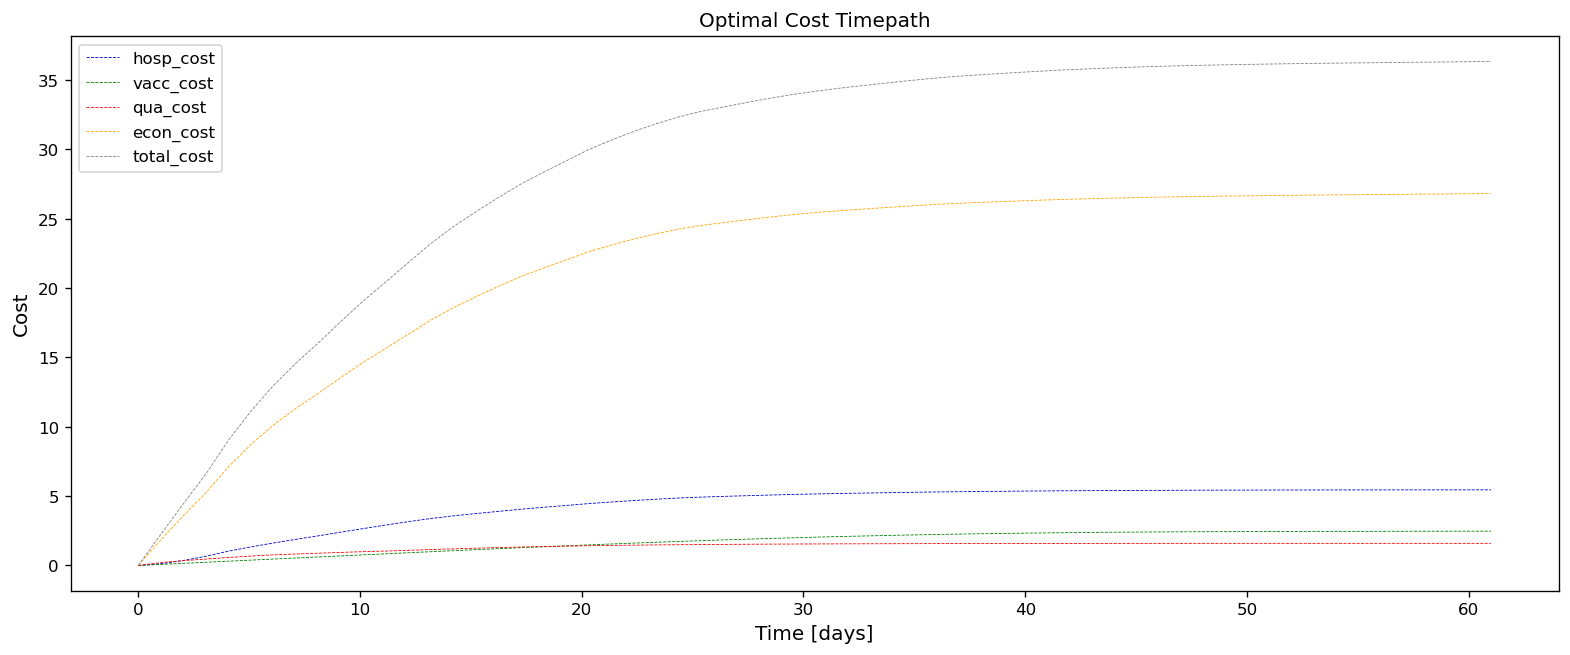

In [28]:
# Cost analysis: optimal vaccination - base case
hosp_opt_cost_partial = np.repeat(0.00, len(S_act))
vacc_opt_cost_partial = np.repeat(0.00, len(S_act))
qua_opt_cost_partial = np.repeat(0.00, len(S_act))
econ_opt_cost_partial = np.repeat(0.00, len(S_act))
total_opt_cost_partial = np.repeat(0.00, len(S_act))

repeated_opt_u = repeated_u

for i in range(1, len(S_opt)):
    hosp_opt_cost_partial[i] = c3 * sum(I1_opt[0:i]*N_path_opt[0:i]) + c4 * sum(I2_opt[0:i]*N_path_opt[0:i]) + c5 * sum(I3_opt[0:i]*N_path_opt[0:i])
    vacc_opt_cost_partial[i] = c1 * sum(repeated_opt_u[0:i]**2)
    qua_opt_cost_partial[i] = c2 * sum(E_opt[0:i]*N_path_opt[0:i])
    econ_opt_cost_partial[i] = c6 * sum(E_opt[0:i]*N_path_opt[0:i]+I1_opt[0:i]*N_path_opt[0:i]+I2_opt[0:i]*N_path_opt[0:i]+I3_opt[0:i]*N_path_opt[0:i]+D_opt[0:i]*N_path_opt[0:i])
    total_opt_cost_partial[i] = hosp_opt_cost_partial[i]+vacc_opt_cost_partial[i]+qua_opt_cost_partial[i]+econ_opt_cost_partial[i]

t = np.linspace(0, len(S_opt), len(S_opt))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_opt_cost_partial, lw = 0.5, ls = '--', color = 'mediumblue', label = 'hosp_cost')
ax0.plot(t, vacc_opt_cost_partial, lw = 0.5, ls = '--', color = 'green', label = 'vacc_cost')
ax0.plot(t, qua_opt_cost_partial, lw = 0.5, ls = '--', color = 'red', label = 'qua_cost')
ax0.plot(t, econ_opt_cost_partial, lw = 0.5, ls = '--', color = 'orange', label = 'econ_cost')
ax0.plot(t, total_opt_cost_partial, lw = 0.5, ls = '--', color = 'grey', label = 'total_cost')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Optimal Cost Timepath', fontsize = 12)
ax0.legend()

#### Strategy 3-2: Optimal Vaccination Rate (sigma=0.05)

In [29]:
repeated_u_sigma_small = np.repeat(u_opt_sigma_small, repeat_times , axis=0)

np.random.seed(123460) #optimal vacc small sigma=0.05 sseed

S_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
V_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
E_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
I1_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
I2_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
I3_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
R_opt_sigma_small = np.zeros(int(t_max/dt) + 1)
D_opt_sigma_small = np.zeros(int(t_max/dt) + 1)

S_opt_sigma_small[0] = S0 #* N_pob
V_opt_sigma_small[0] = V0 #* N_pob
E_opt_sigma_small[0] = E0 #* N_pob
I1_opt_sigma_small[0] = I10 #* N_pob
I2_opt_sigma_small[0] = I20 #* N_pob
I3_opt_sigma_small[0] = I30 #* N_pob
R_opt_sigma_small[0] = R0 #* N_pob
D_opt_sigma_small[0] = D0 #* N_pob

for i in range(1, len(S_opt_sigma_small)):
 
    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()
 
    dS = (birth - ( beta1 * I1_opt_sigma_small[i-1] + beta2 * I2_opt_sigma_small[i-1] + beta3 * I3_opt_sigma_small[i-1]) * S_opt_sigma_small[i-1] - repeated_u_sigma_small[i-1] * S_opt_sigma_small[i-1] - death* S_opt_sigma_small[i-1]) 
    dV = (repeated_u_sigma_small[i-1] * S_opt_sigma_small[i-1] - sigma * (beta1 * I1_opt_sigma_small[i-1] + beta2 * I2_opt_sigma_small[i-1] + beta3 * I3_opt_sigma_small[i-1]) * V_opt_sigma_small[i-1] - death* V_opt_sigma_small[i-1])  
    dE = ((beta1 * I1_opt_sigma_small[i-1] + beta2 * I2_opt_sigma_small[i-1] + beta3 * I3_opt_sigma_small[i-1]) * S_opt_sigma_small[i-1]  \
          + sigma * (beta1 * I1_opt_sigma_small[i-1] + beta2 * I2_opt_sigma_small[i-1] + beta3 * I3_opt_sigma_small[i-1]) * V_opt_sigma_small[i-1] - gamma * E_opt_sigma_small[i-1]- death* E_opt_sigma_small[i-1]) 
    dI1 = (gamma * E_opt_sigma_small[i-1] - (delta1 + p1fn(repeated_u_sigma_small[i-1])) * I1_opt_sigma_small[i-1]- death* I1_opt_sigma_small[i-1]) 
    dI2 = (p1fn(repeated_u_sigma_small[i-1]) * I1_opt_sigma_small[i-1] - (delta2 + p2) * I2_opt_sigma_small[i-1]- death* I2_opt_sigma_small[i-1]) 
    dI3 = (p2 * I2_opt_sigma_small[i-1] - (delta3 + mu) * I3_opt_sigma_small[i-1]- death* I3_opt_sigma_small[i-1]) 
    dR = (delta1 * I1_opt_sigma_small[i-1]+ delta2 * I2_opt_sigma_small[i-1] + delta3 * I3_opt_sigma_small[i-1]- death* R_opt_sigma_small[i-1]) 
    dD = (mu * I3_opt_sigma_small[i-1])

    S_opt_sigma_small[i] = S_opt_sigma_small[i-1] + dS * dt + sigma1 * sigma_small * S_opt_sigma_small[i-1] * sqrt_dt * dW1
    V_opt_sigma_small[i] = V_opt_sigma_small[i-1] + dV * dt + sigma2 *sigma_small * V_opt_sigma_small[i-1] * sqrt_dt * dW2
    E_opt_sigma_small[i] = E_opt_sigma_small[i-1] + dE * dt + sigma3 *sigma_small * E_opt_sigma_small[i-1] * sqrt_dt * dW3
    I1_opt_sigma_small[i] = I1_opt_sigma_small[i-1] + dI1 * dt + sigma4 *sigma_small * I1_opt_sigma_small[i-1] * sqrt_dt * dW4
    I2_opt_sigma_small[i] = I2_opt_sigma_small[i-1] + dI2 * dt + sigma5 *sigma_small * I2_opt_sigma_small[i-1] * sqrt_dt * dW5
    I3_opt_sigma_small[i] = I3_opt_sigma_small[i-1] + dI3 * dt + sigma6 *sigma_small * I3_opt_sigma_small[i-1] * sqrt_dt * dW6
    R_opt_sigma_small[i] = R_opt_sigma_small[i-1] + dR * dt + sigma7 *sigma_small * R_opt_sigma_small[i-1] * sqrt_dt * dW7
    D_opt_sigma_small[i] = D_opt_sigma_small[i-1] + dD * dt + sigma8 *sigma_small * D_opt_sigma_small[i-1] * sqrt_dt * dW8
    
    N_opt_sigma_small = S_opt_sigma_small[i] + V_opt_sigma_small[i] + E_opt_sigma_small[i] + I1_opt_sigma_small[i] + I2_opt_sigma_small[i] + I3_opt_sigma_small[i] + R_opt_sigma_small[i] + D_opt_sigma_small[i]

    if i % 30 == 0:  # print every 30 steps
        print(f"Step {i}: S = {S_opt_sigma_small[i]/N_opt_sigma_small}, V = {V_opt_sigma_small[i]/N_opt_sigma_small},  E = {E_opt_sigma_small[i]/N_opt_sigma_small},  I1 = {I1_opt_sigma_small[i]/N_opt_sigma_small},  I2 = {I2_opt_sigma_small[i]/N_opt_sigma_small},  I3 = {I3_opt_sigma_small[i]/N_opt_sigma_small}, R = {R_opt_sigma_small[i]/N_opt_sigma_small}, D = {D_opt_sigma_small[i]/N_opt_sigma_small}, u = {repeated_u_sigma_small[i-1]}")


Step 30: S = 0.2783791374077165, V = 0.6997320179956926,  E = 0.00016681610409501602,  I1 = 0.0002951580438056867,  I2 = 3.1288692734154e-06,  I3 = 9.45876649186315e-06, R = 0.02127109218381604, D = 0.000143190629108726, u = 0.0216
Step 60: S = 0.26976213069507554, V = 0.71241555012393,  E = 1.7668117534924155e-06,  I1 = 3.71788628139422e-06,  I2 = 7.36231820510211e-08,  I3 = 2.9628391304815447e-07, R = 0.01768157187194525, D = 0.00013489270391897203, u = 0.0052


In [30]:
N_path_sigma_small = S_opt_sigma_small + V_opt_sigma_small + E_opt_sigma_small + I1_opt_sigma_small + I2_opt_sigma_small + I3_opt_sigma_small + R_opt_sigma_small + D_opt_sigma_small

# cost table
hosp_cost_sigma_small = c3 * sum(I1_opt_sigma_small*N_path_sigma_small) + c4 * sum(I2_opt_sigma_small*N_path_sigma_small) + c5 * sum(I3_opt_sigma_small*N_path_sigma_small)
vacc_cost_sigma_small = c1 * sum(repeated_u_sigma_small**2)
qua_cost_sigma_small = c2 * sum(E_opt_sigma_small*N_path_sigma_small)
econ_cost_sigma_small = c6 * sum(E_opt_sigma_small*N_path_sigma_small + I1_opt_sigma_small*N_path_sigma_small+I2_opt_sigma_small*N_path_sigma_small+I3_opt_sigma_small*N_path_sigma_small + D_opt_sigma_small*N_path_sigma_small)

total_cost_sigma_small = hosp_cost_sigma_small+vacc_cost_sigma_small+qua_cost_sigma_small+econ_cost_sigma_small

data_sigma_small_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'Value': [hosp_cost_sigma_small, vacc_cost_sigma_small+qua_cost_sigma_small, econ_cost_sigma_small],
                  'Percentage': [format(hosp_cost_sigma_small/total_cost_sigma_small * 100, ".2f") + "%",
                                 format((vacc_cost_sigma_small+qua_cost_sigma_small)/total_cost_sigma_small * 100, ".2f") + "%",
                                 format(econ_cost_sigma_small/total_cost_sigma_small * 100, ".2f") + "%"] }
df_sigma_small = pd.DataFrame(data_sigma_small_table)
df_sigma_small.set_index('Type', inplace=True)
print(df_sigma_small)
print('Totoal Cost',total_cost_sigma_small)

                 Value Percentage
Type                             
Hosp Cost     4.793994     15.21%
Policy Cost   3.554672     11.28%
Econ Cost    23.178123     73.52%
Totoal Cost 31.526788590056164


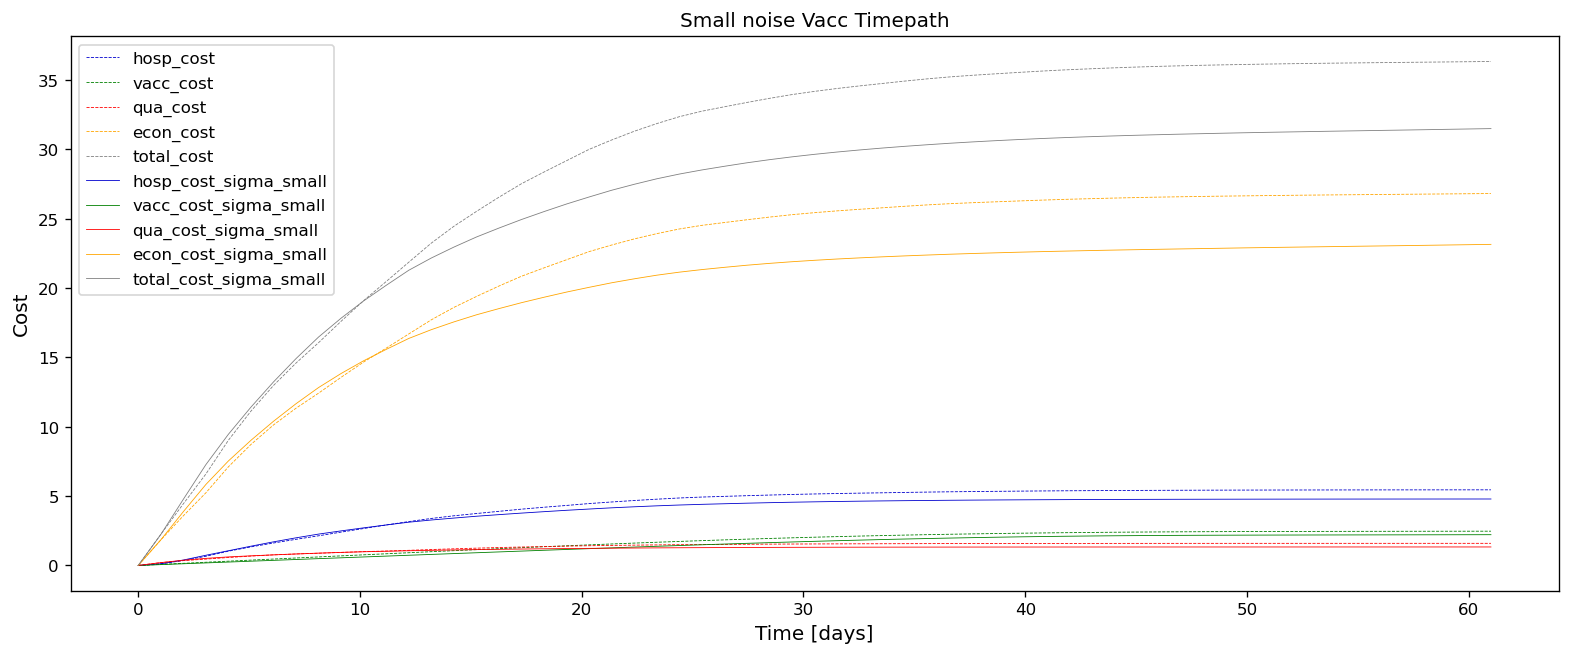

In [31]:
# Cost analysis
hosp_opt_cost_partial_sigma_small = np.repeat(0.00, len(S_opt_sigma_small))
vacc_opt_cost_partial_sigma_small = np.repeat(0.00, len(S_opt_sigma_small))
qua_opt_cost_partial_sigma_small = np.repeat(0.00, len(S_opt_sigma_small))
econ_opt_cost_partial_sigma_small = np.repeat(0.00, len(S_opt_sigma_small))
total_opt_cost_partial_sigma_small = np.repeat(0.00, len(S_opt_sigma_small))

N_path_opt_sigma_small = S_opt_sigma_small + V_opt_sigma_small + E_opt_sigma_small + I1_opt_sigma_small + I2_opt_sigma_small + I3_opt_sigma_small + R_opt_sigma_small + D_opt_sigma_small


for i in range(1, len(S_opt_sigma_small)):
    hosp_opt_cost_partial_sigma_small[i] = c3 * sum(I1_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i]) + c4 * sum(I2_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i]) + c5 * sum(I3_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i])
    vacc_opt_cost_partial_sigma_small[i] = c1 * sum(repeated_u_sigma_small[0:i]**2)
    qua_opt_cost_partial_sigma_small[i] = c2 * sum(E_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i])
    econ_opt_cost_partial_sigma_small[i] = c6 * sum(E_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i]+I1_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i]+I2_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i]+I3_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i]+D_opt_sigma_small[0:i]*N_path_opt_sigma_small[0:i])
    total_opt_cost_partial_sigma_small[i] = hosp_opt_cost_partial_sigma_small[i]+vacc_opt_cost_partial_sigma_small[i]+qua_opt_cost_partial_sigma_small[i]+econ_opt_cost_partial_sigma_small[i]


t = np.linspace(0, len(S_opt_sigma_small), len(S_opt_sigma_small))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_opt_cost_partial, lw = 0.5, ls = '--', color = 'mediumblue', label = 'hosp_cost')
ax0.plot(t, vacc_opt_cost_partial, lw = 0.5, ls = '--', color = 'green', label = 'vacc_cost')
ax0.plot(t, qua_opt_cost_partial, lw = 0.5, ls = '--', color = 'red', label = 'qua_cost')
ax0.plot(t, econ_opt_cost_partial, lw = 0.5, ls = '--', color = 'orange', label = 'econ_cost')
ax0.plot(t, total_opt_cost_partial, lw = 0.5, ls = '--', color = 'grey', label = 'total_cost')

ax0.plot(t, hosp_opt_cost_partial_sigma_small, lw = 0.5,  color = 'mediumblue', label = 'hosp_cost_sigma_small')
ax0.plot(t, vacc_opt_cost_partial_sigma_small, lw = 0.5,  color = 'green', label = 'vacc_cost_sigma_small')
ax0.plot(t, qua_opt_cost_partial_sigma_small, lw = 0.5,  color = 'red', label = 'qua_cost_sigma_small')
ax0.plot(t, econ_opt_cost_partial_sigma_small, lw = 0.5, color = 'orange', label = 'econ_cost_sigma_small')
ax0.plot(t, total_opt_cost_partial_sigma_small, lw = 0.5,  color = 'grey', label = 'total_cost_sigma_small')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Small noise Vacc Timepath', fontsize = 12)
ax0.legend()

In [32]:
### Strategy 3-3: Optimal Vaccination Rate (sigma=0.2)

In [33]:
repeated_u_sigma_large = np.repeat(u_opt_sigma_large, repeat_times , axis=0)

np.random.seed(18) #optimal vacc small sigma=0.2 seeed

S_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
V_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
E_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
I1_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
I2_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
I3_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
R_opt_sigma_large = np.zeros(int(t_max/dt) + 1)
D_opt_sigma_large = np.zeros(int(t_max/dt) + 1)

S_opt_sigma_large[0] = S0 #* N_pob
V_opt_sigma_large[0] = V0 #* N_pob
E_opt_sigma_large[0] = E0 #* N_pob
I1_opt_sigma_large[0] = I10 #* N_pob
I2_opt_sigma_large[0] = I20 #* N_pob
I3_opt_sigma_large[0] = I30 #* N_pob
R_opt_sigma_large[0] = R0 #* N_pob
D_opt_sigma_large[0] = D0 #* N_pob

for i in range(1, len(S_opt_sigma_large)):
 
    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()
 
    dS = (birth - ( beta1 * I1_opt_sigma_large[i-1] + beta2 * I2_opt_sigma_large[i-1] + beta3 * I3_opt_sigma_large[i-1]) * S_opt_sigma_large[i-1] - repeated_u_sigma_large[i-1] * S_opt_sigma_large[i-1] - death* S_opt_sigma_large[i-1]) 
    dV = (repeated_u_sigma_large[i-1] * S_opt_sigma_large[i-1] - sigma * (beta1 * I1_opt_sigma_large[i-1] + beta2 * I2_opt_sigma_large[i-1] + beta3 * I3_opt_sigma_large[i-1]) * V_opt_sigma_large[i-1] - death* V_opt_sigma_large[i-1])  
    dE = ((beta1 * I1_opt_sigma_large[i-1] + beta2 * I2_opt_sigma_large[i-1] + beta3 * I3_opt_sigma_large[i-1]) * S_opt_sigma_large[i-1]  \
          + sigma * (beta1 * I1_opt_sigma_large[i-1] + beta2 * I2_opt_sigma_large[i-1] + beta3 * I3_opt_sigma_large[i-1]) * V_opt_sigma_large[i-1] - gamma * E_opt_sigma_large[i-1]- death* E_opt_sigma_large[i-1]) 
    dI1 = (gamma * E_opt_sigma_large[i-1] - (delta1 + p1fn(repeated_u_sigma_large[i-1])) * I1_opt_sigma_large[i-1]- death* I1_opt_sigma_large[i-1]) 
    dI2 = (p1fn(repeated_u_sigma_large[i-1]) * I1_opt_sigma_large[i-1] - (delta2 + p2) * I2_opt_sigma_large[i-1]- death* I2_opt_sigma_large[i-1]) 
    dI3 = (p2 * I2_opt_sigma_large[i-1] - (delta3 + mu) * I3_opt_sigma_large[i-1]- death* I3_opt_sigma_large[i-1]) 
    dR = (delta1 * I1_opt_sigma_large[i-1]+ delta2 * I2_opt_sigma_large[i-1] + delta3 * I3_opt_sigma_large[i-1]- death* R_opt_sigma_large[i-1]) 
    dD = (mu * I3_opt_sigma_large[i-1])

    S_opt_sigma_large[i] = S_opt_sigma_large[i-1] + dS * dt + sigma1 *sigma_large * S_opt_sigma_large[i-1] * sqrt_dt * dW1 
    V_opt_sigma_large[i] = V_opt_sigma_large[i-1] + dV * dt + sigma2 *sigma_large * V_opt_sigma_large[i-1] * sqrt_dt * dW2
    E_opt_sigma_large[i] = E_opt_sigma_large[i-1] + dE * dt + sigma3 *sigma_large * E_opt_sigma_large[i-1] * sqrt_dt * dW3
    I1_opt_sigma_large[i] = I1_opt_sigma_large[i-1] + dI1 * dt + sigma4 *sigma_large * I1_opt_sigma_large[i-1] * sqrt_dt * dW4
    I2_opt_sigma_large[i] = I2_opt_sigma_large[i-1] + dI2 * dt + sigma5 *sigma_large * I2_opt_sigma_large[i-1] * sqrt_dt * dW5
    I3_opt_sigma_large[i] = I3_opt_sigma_large[i-1] + dI3 * dt + sigma6 *sigma_large * I3_opt_sigma_large[i-1] * sqrt_dt * dW6
    R_opt_sigma_large[i] = R_opt_sigma_large[i-1] + dR * dt + sigma7 *sigma_large * R_opt_sigma_large[i-1] * sqrt_dt * dW7
    D_opt_sigma_large[i] = D_opt_sigma_large[i-1] + dD * dt + sigma8 *sigma_large * D_opt_sigma_large[i-1] * sqrt_dt * dW8
    
    N_opt_sigma_large = S_opt_sigma_large[i] + V_opt_sigma_large[i] + E_opt_sigma_large[i] + I1_opt_sigma_large[i] + I2_opt_sigma_large[i] + I3_opt_sigma_large[i] + R_opt_sigma_large[i] + D_opt_sigma_large[i]

    if i % 30 == 0:  # print every 30 steps
        print(f"Step {i}: S = {S_opt_sigma_large[i]/N_opt_sigma_large}, V = {V_opt_sigma_large[i]/N_opt_sigma_large},  E = {E_opt_sigma_large[i]/N_opt_sigma_large},  I1 = {I1_opt_sigma_large[i]/N_opt_sigma_large},  I2 = {I2_opt_sigma_large[i]/N_opt_sigma_large},  I3 = {I3_opt_sigma_large[i]/N_opt_sigma_large}, R = {R_opt_sigma_large[i]/N_opt_sigma_large}, D = {D_opt_sigma_large[i]/N_opt_sigma_large}, u = {repeated_u_sigma_large[i-1]}")



Step 30: S = 0.3990434051737153, V = 0.5748175423844043,  E = 0.00018439961784333988,  I1 = 0.0002561417673259884,  I2 = 2.70499464244383e-06,  I3 = 7.060596141997776e-06, R = 0.02561083317895016, D = 7.791228697643404e-05, u = 0.0198
Step 60: S = 0.01702896503165176, V = 0.9525730671114215,  E = 7.961704976199057e-07,  I1 = 4.2103309485327365e-06,  I2 = 1.0211535756347142e-07,  I3 = 3.042981746991367e-07, R = 0.030318309072195605, D = 7.424586975255374e-05, u = 0.0052


In [34]:
N_path_sigma_large = S_opt_sigma_large + V_opt_sigma_large + E_opt_sigma_large + I1_opt_sigma_large + I2_opt_sigma_large + I3_opt_sigma_large + R_opt_sigma_large + D_opt_sigma_large

# create a result table
hosp_cost_sigma_large = c3 * sum(I1_opt_sigma_large*N_path_sigma_large) + c4 * sum(I2_opt_sigma_large*N_path_sigma_large) + c5 * sum(I3_opt_sigma_large*N_path_sigma_large)
vacc_cost_sigma_large = c1 * sum(repeated_u_sigma_large**2)
qua_cost_sigma_large = c2 * sum(E_opt_sigma_large*N_path_sigma_large)
econ_cost_sigma_large = c6 * sum(E_opt_sigma_large*N_path_sigma_large + I1_opt_sigma_large*N_path_sigma_large+I2_opt_sigma_large*N_path_sigma_large+I3_opt_sigma_large*N_path_sigma_large + D_opt_sigma_large*N_path_sigma_large)

total_cost_sigma_large = hosp_cost_sigma_large+vacc_cost_sigma_large+qua_cost_sigma_large+econ_cost_sigma_large

data_sigma_large_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'Value': [hosp_cost_sigma_large, vacc_cost_sigma_large+qua_cost_sigma_large, econ_cost_sigma_large],
                  'Percentage': [format(hosp_cost_sigma_large/total_cost_sigma_large * 100, ".2f") + "%",
                                 format((vacc_cost_sigma_large+qua_cost_sigma_large)/total_cost_sigma_large * 100, ".2f") + "%",
                                 format(econ_cost_sigma_large/total_cost_sigma_large * 100, ".2f") + "%"] }
df_sigma_large = pd.DataFrame(data_sigma_large_table)
df_sigma_large.set_index('Type', inplace=True)
print(df_sigma_large)
print('Totoal Cost',total_cost_sigma_large)

                 Value Percentage
Type                             
Hosp Cost     6.298334     15.54%
Policy Cost   4.035550      9.96%
Econ Cost    30.195958     74.50%
Totoal Cost 40.52984158197518


In [35]:
### Strategy 3-4 tiny noise sigma=0.0002

In [36]:

repeated_u_sigma_tiny = np.repeat(u_opt_sigma_tiny, repeat_times , axis=0)

np.random.seed(111) #optimal vacc small sigma=0.0002

S_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
V_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
E_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
I1_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
I2_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
I3_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
R_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)
D_opt_sigma_tiny = np.zeros(int(t_max/dt) + 1)

S_opt_sigma_tiny[0] = S0 #* N_pob
V_opt_sigma_tiny[0] = V0 #* N_pob
E_opt_sigma_tiny[0] = E0 #* N_pob
I1_opt_sigma_tiny[0] = I10 #* N_pob
I2_opt_sigma_tiny[0] = I20 #* N_pob
I3_opt_sigma_tiny[0] = I30 #* N_pob
R_opt_sigma_tiny[0] = R0 #* N_pob
D_opt_sigma_tiny[0] = D0 #* N_pob

for i in range(1, len(S_opt_sigma_tiny)):
 
    dW1 = np.random.randn()
    dW2 = np.random.randn()
    dW3 = np.random.randn()
    dW4 = np.random.randn()
    dW5 = np.random.randn()
    dW6 = np.random.randn()
    dW7 = np.random.randn()
    dW8 = np.random.randn()
 
    dS = (birth - ( beta1 * I1_opt_sigma_tiny[i-1] + beta2 * I2_opt_sigma_tiny[i-1] + beta3 * I3_opt_sigma_tiny[i-1]) * S_opt_sigma_tiny[i-1] - repeated_u_sigma_tiny[i-1] * S_opt_sigma_tiny[i-1] - death* S_opt_sigma_tiny[i-1]) 
    dV = (repeated_u_sigma_tiny[i-1] * S_opt_sigma_tiny[i-1] - sigma * (beta1 * I1_opt_sigma_tiny[i-1] + beta2 * I2_opt_sigma_tiny[i-1] + beta3 * I3_opt_sigma_tiny[i-1]) * V_opt_sigma_tiny[i-1] - death* V_opt_sigma_tiny[i-1])  
    dE = ((beta1 * I1_opt_sigma_tiny[i-1] + beta2 * I2_opt_sigma_tiny[i-1] + beta3 * I3_opt_sigma_tiny[i-1]) * S_opt_sigma_tiny[i-1]  \
          + sigma * (beta1 * I1_opt_sigma_tiny[i-1] + beta2 * I2_opt_sigma_tiny[i-1] + beta3 * I3_opt_sigma_tiny[i-1]) * V_opt_sigma_tiny[i-1] - gamma * E_opt_sigma_tiny[i-1]- death* E_opt_sigma_tiny[i-1]) 
    dI1 = (gamma * E_opt_sigma_tiny[i-1] - (delta1 + p1fn(repeated_u_sigma_tiny[i-1])) * I1_opt_sigma_tiny[i-1]- death* I1_opt_sigma_tiny[i-1]) 
    dI2 = (p1fn(repeated_u_sigma_tiny[i-1]) * I1_opt_sigma_tiny[i-1] - (delta2 + p2) * I2_opt_sigma_tiny[i-1]- death* I2_opt_sigma_tiny[i-1]) 
    dI3 = (p2 * I2_opt_sigma_tiny[i-1] - (delta3 + mu) * I3_opt_sigma_tiny[i-1]- death* I3_opt_sigma_tiny[i-1]) 
    dR = (delta1 * I1_opt_sigma_tiny[i-1]+ delta2 * I2_opt_sigma_tiny[i-1] + delta3 * I3_opt_sigma_tiny[i-1]- death* R_opt_sigma_tiny[i-1]) 
    dD = (mu * I3_opt_sigma_tiny[i-1])

    S_opt_sigma_tiny[i] = S_opt_sigma_tiny[i-1] + dS * dt + sigma1 *sigma_tiny * S_opt_sigma_tiny[i-1] * sqrt_dt * dW1 
    V_opt_sigma_tiny[i] = V_opt_sigma_tiny[i-1] + dV * dt + sigma2 *sigma_tiny * V_opt_sigma_tiny[i-1] * sqrt_dt * dW2
    E_opt_sigma_tiny[i] = E_opt_sigma_tiny[i-1] + dE * dt + sigma3 *sigma_tiny * E_opt_sigma_tiny[i-1] * sqrt_dt * dW3
    I1_opt_sigma_tiny[i] = I1_opt_sigma_tiny[i-1] + dI1 * dt + sigma4 *sigma_tiny * I1_opt_sigma_tiny[i-1] * sqrt_dt * dW4
    I2_opt_sigma_tiny[i] = I2_opt_sigma_tiny[i-1] + dI2 * dt + sigma5 *sigma_tiny * I2_opt_sigma_tiny[i-1] * sqrt_dt * dW5
    I3_opt_sigma_tiny[i] = I3_opt_sigma_tiny[i-1] + dI3 * dt + sigma6 *sigma_tiny * I3_opt_sigma_tiny[i-1] * sqrt_dt * dW6
    R_opt_sigma_tiny[i] = R_opt_sigma_tiny[i-1] + dR * dt + sigma7 *sigma_tiny * R_opt_sigma_tiny[i-1] * sqrt_dt * dW7
    D_opt_sigma_tiny[i] = D_opt_sigma_tiny[i-1] + dD * dt + sigma8 *sigma_tiny * D_opt_sigma_tiny[i-1] * sqrt_dt * dW8
    
    N_opt_sigma_tiny = S_opt_sigma_tiny[i] + V_opt_sigma_tiny[i] + E_opt_sigma_tiny[i] + I1_opt_sigma_tiny[i] + I2_opt_sigma_tiny[i] + I3_opt_sigma_tiny[i] + R_opt_sigma_tiny[i] + D_opt_sigma_tiny[i]

    if i % 30 == 0:  # print every 30 steps
        print(f"Step {i}: S = {S_opt_sigma_tiny[i]/N_opt_sigma_tiny}, V = {V_opt_sigma_tiny[i]/N_opt_sigma_tiny},  E = {E_opt_sigma_tiny[i]/N_opt_sigma_tiny},  I1 = {I1_opt_sigma_tiny[i]/N_opt_sigma_tiny},  I2 = {I2_opt_sigma_tiny[i]/N_opt_sigma_tiny},  I3 = {I3_opt_sigma_tiny[i]/N_opt_sigma_tiny}, R = {R_opt_sigma_tiny[i]/N_opt_sigma_tiny}, D = {D_opt_sigma_tiny[i]/N_opt_sigma_tiny}, u = {repeated_u_sigma_tiny[i-1]}")



Step 30: S = 0.315383338031098, V = 0.6571255651036849,  E = 0.0001745767246260409,  I1 = 0.000327419546626559,  I2 = 5.596063849380235e-06,  I3 = 1.186395965109275e-05, R = 0.02682980993777979, D = 0.00014183063268418408, u = 0.0053
Step 60: S = 0.27955009092593064, V = 0.6927309405009969,  E = 2.545953608653863e-06,  I1 = 5.004638328825679e-06,  I2 = 9.002438574495209e-08,  I3 = 4.4182300830076846e-07, R = 0.02756514730986836, D = 0.00014573882387251166, u = 0.0052


In [37]:
N_path_sigma_tiny = S_opt_sigma_tiny + V_opt_sigma_tiny + E_opt_sigma_tiny + I1_opt_sigma_tiny + I2_opt_sigma_tiny + I3_opt_sigma_tiny + R_opt_sigma_tiny + D_opt_sigma_tiny

# create a result table
hosp_cost_sigma_tiny = c3 * sum(I1_opt_sigma_tiny*N_path_sigma_tiny) + c4 * sum(I2_opt_sigma_tiny*N_path_sigma_tiny) + c5 * sum(I3_opt_sigma_tiny*N_path_sigma_tiny)
vacc_cost_sigma_tiny = c1 * sum(repeated_u_sigma_tiny**2)
qua_cost_sigma_tiny = c2 * sum(E_opt_sigma_tiny*N_path_sigma_tiny)
econ_cost_sigma_tiny = c6 * sum(E_opt_sigma_tiny*N_path_sigma_tiny + I1_opt_sigma_tiny*N_path_sigma_tiny+I2_opt_sigma_tiny*N_path_sigma_tiny+I3_opt_sigma_tiny*N_path_sigma_tiny + D_opt_sigma_tiny*N_path_sigma_tiny)

total_cost_sigma_tiny = hosp_cost_sigma_tiny+vacc_cost_sigma_tiny+qua_cost_sigma_tiny+econ_cost_sigma_tiny

data_sigma_tiny_table = {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost'],
                  'Value': [hosp_cost_sigma_tiny, vacc_cost_sigma_tiny+qua_cost_sigma_tiny, econ_cost_sigma_tiny],
                  'Percentage': [format(hosp_cost_sigma_tiny/total_cost_sigma_tiny * 100, ".2f") + "%",
                                 format((vacc_cost_sigma_tiny+qua_cost_sigma_tiny)/total_cost_sigma_tiny * 100, ".2f") + "%",
                                 format(econ_cost_sigma_tiny/total_cost_sigma_tiny * 100, ".2f") + "%"] }
df_sigma_tiny = pd.DataFrame(data_sigma_tiny_table)
df_sigma_tiny.set_index('Type', inplace=True)
print(df_sigma_tiny)
print('Totoal Cost',total_cost_sigma_tiny)

                 Value Percentage
Type                             
Hosp Cost     4.829627     16.00%
Policy Cost   2.413340      8.00%
Econ Cost    22.939450     76.00%
Totoal Cost 30.182417421122565


## State Population change Result graph combined

In [38]:
N_path_con = S_con + V_con + E_con + I1_con + I2_con + I3_con + R_con + D_con
N_path_act = S_act + V_act + E_act + I1_act + I2_act + I3_act + R_act + D_act
N_path_opt = S + V + E + I1 + I2 + I3 + R + D
N_path_ori = S_ori + V_ori + E_ori + I1_ori + I2_ori + I3_ori + R_ori + D_ori

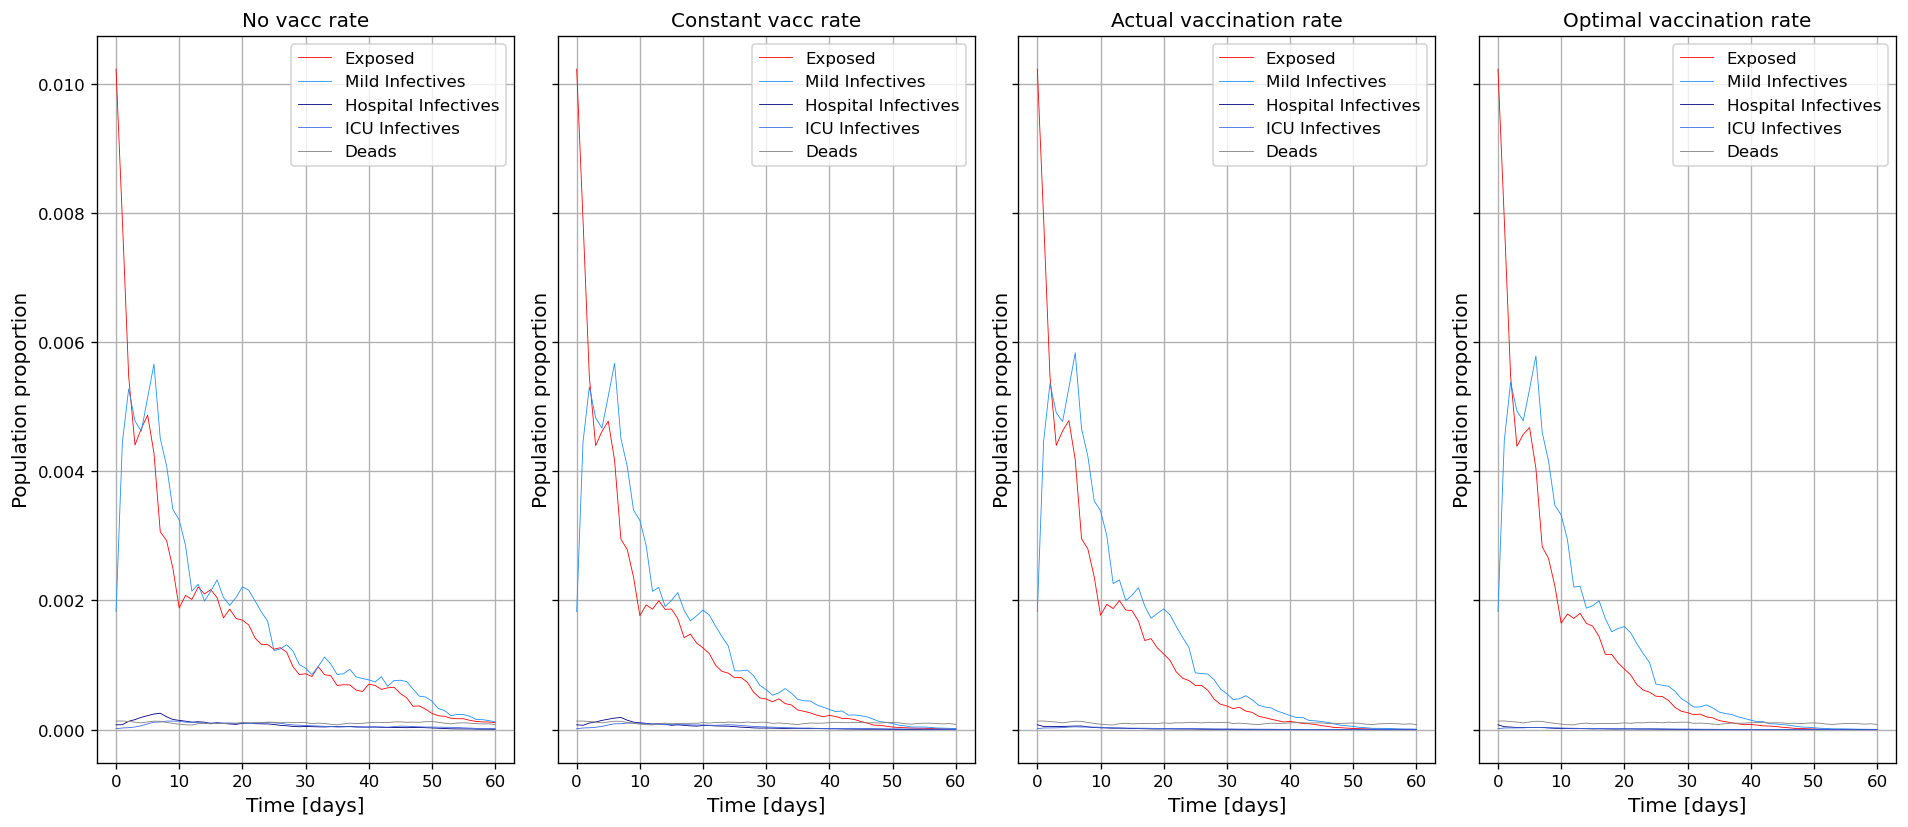

In [39]:
t = np.linspace(0, t_max, len(S))
fig, (ax0, ax1, ax2, ax3) = plt.subplots(1, 4, figsize =(16,7), dpi = 120, sharey = True)

# Strategy 0: no vaccination rate
#ax0.plot(t, S_ori/N_path_ori, lw = 0.5, color = 'purple', label = 'Susceptibles')
#ax0.plot(t, V_ori/N_path_ori, lw = 0.5, color = 'red', label = 'Vaccinated')
ax0.plot(t, E_ori/N_path_ori, lw = 0.5, color = 'red', label = 'Exposed')
ax0.plot(t, I1_ori/N_path_ori, lw = 0.5, color = 'dodgerblue', label = 'Mild Infectives')
ax0.plot(t, I2_ori/N_path_ori, lw = 0.5, color = 'navy', label = 'Hospital Infectives')
ax0.plot(t, I3_ori/N_path_ori, lw = 0.5, color = 'royalblue', label = 'ICU Infectives')
#ax0.plot(t, R_ori/N_path_ori, lw = 0.5, color = 'forestgreen', label = 'Recovered')
ax0.plot(t, D_ori/N_path_ori, lw = 0.5, color = 'grey', label = 'Deads')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('No vacc rate', fontsize = 12)


# Strategy 1: constant vaccination rate
#ax1.plot(t, S_con/N_path_con, lw = 0.5, color = 'purple', label = 'Susceptibles')
#ax1.plot(t, V_con/N_path_con, lw = 0.5, color = 'red', label = 'Vaccinated')
ax1.plot(t, E_con/N_path_con, lw = 0.5, color = 'red', label = 'Exposed')
ax1.plot(t, I1_con/N_path_con, lw = 0.5, color = 'dodgerblue', label = 'Mild Infectives')
ax1.plot(t, I2_con/N_path_con, lw = 0.5, color = 'navy', label = 'Hospital Infectives')
ax1.plot(t, I3_con/N_path_con, lw = 0.5, color = 'royalblue', label = 'ICU Infectives')
#ax1.plot(t, R_con/N_path_con, lw = 0.5, color = 'forestgreen', label = 'Recovered')
ax1.plot(t, D_con/N_path_con, lw = 0.5, color = 'grey', label = 'Deads')

ax1.set_xlabel('Time [days]', fontsize = 12)
ax1.set_ylabel('Population proportion', fontsize = 12)
ax1.set_title('Constant vacc rate', fontsize = 12)

# Strategy 2: actual vaccination rate
#ax2.plot(t, S_act/N_path_act, lw = 0.5, color = 'purple', label = 'Susceptibles')
#ax2.plot(t, V_act/N_path_act, lw = 0.5, color = 'red', label = 'Vaccinated')
ax2.plot(t, E_act/N_path_act, lw = 0.5, color = 'red', label = 'Exposed')
ax2.plot(t, I1_act/N_path_act, lw = 0.5, color = 'dodgerblue', label = 'Mild Infectives')
ax2.plot(t, I2_act/N_path_act, lw = 0.5, color = 'navy', label = 'Hospital Infectives')
ax2.plot(t, I3_act/N_path_act, lw = 0.5, color = 'royalblue', label = 'ICU Infectives')
#ax2.plot(t, R_act/N_path_act, lw = 0.5, color = 'forestgreen', label = 'Recovered')
ax2.plot(t, D_act/N_path_act, lw = 0.5, color = 'grey', label = 'Deads')

ax2.set_xlabel('Time [days]', fontsize = 12)
ax2.set_ylabel('Population proportion', fontsize = 12)
ax2.set_title('Actual vaccination rate', fontsize = 12)

# Strategy 3-1: optimal stochastic vaccination rate
#ax3.plot(t, S/N_path_opt, lw = 0.5, color = 'purple', label = 'Susceptibles')
#ax3.plot(t, V/N_path_opt, lw = 0.5, color = 'red', label = 'Vaccinated')
ax3.plot(t, E/N_path_opt, lw = 0.5, color = 'red', label = 'Exposed')
ax3.plot(t, I1/N_path_opt, lw = 0.5, color = 'dodgerblue', label = 'Mild Infectives')
ax3.plot(t, I2/N_path_opt, lw = 0.5, color = 'navy', label = 'Hospital Infectives')
ax3.plot(t, I3/N_path_opt, lw = 0.5, color = 'royalblue', label = 'ICU Infectives')
#ax3.plot(t, R/N_path_opt, lw = 0.5, color = 'forestgreen', label = 'Recovered')
ax3.plot(t, D/N_path_opt, lw = 0.5, color = 'grey', label = 'Deads')

ax3.set_xlabel('Time [days]', fontsize = 12)
ax3.set_ylabel('Population proportion', fontsize = 12)
ax3.set_title('Optimal vaccination rate', fontsize = 12)

# labels
ax0.legend()
ax1.legend()
ax2.legend()
ax3.legend()
ax0.grid()
ax1.grid()
ax2.grid()
ax3.grid()


plt.tight_layout()
plt.savefig('comparsion for diff strategies.png')

In [40]:
#### Separate State graphs

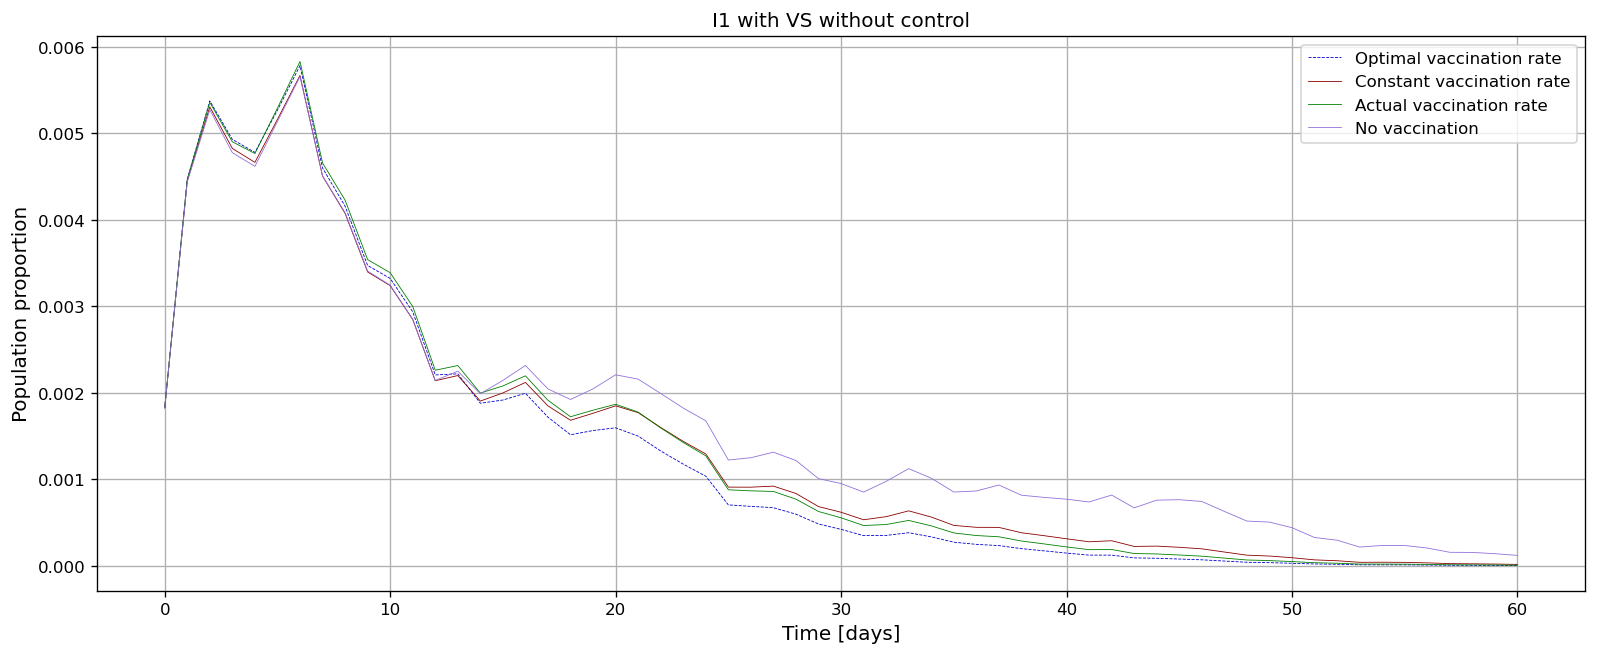

In [41]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, I1/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, I1_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, I1_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, I1_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('I1 with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('I1_popn_change.png')

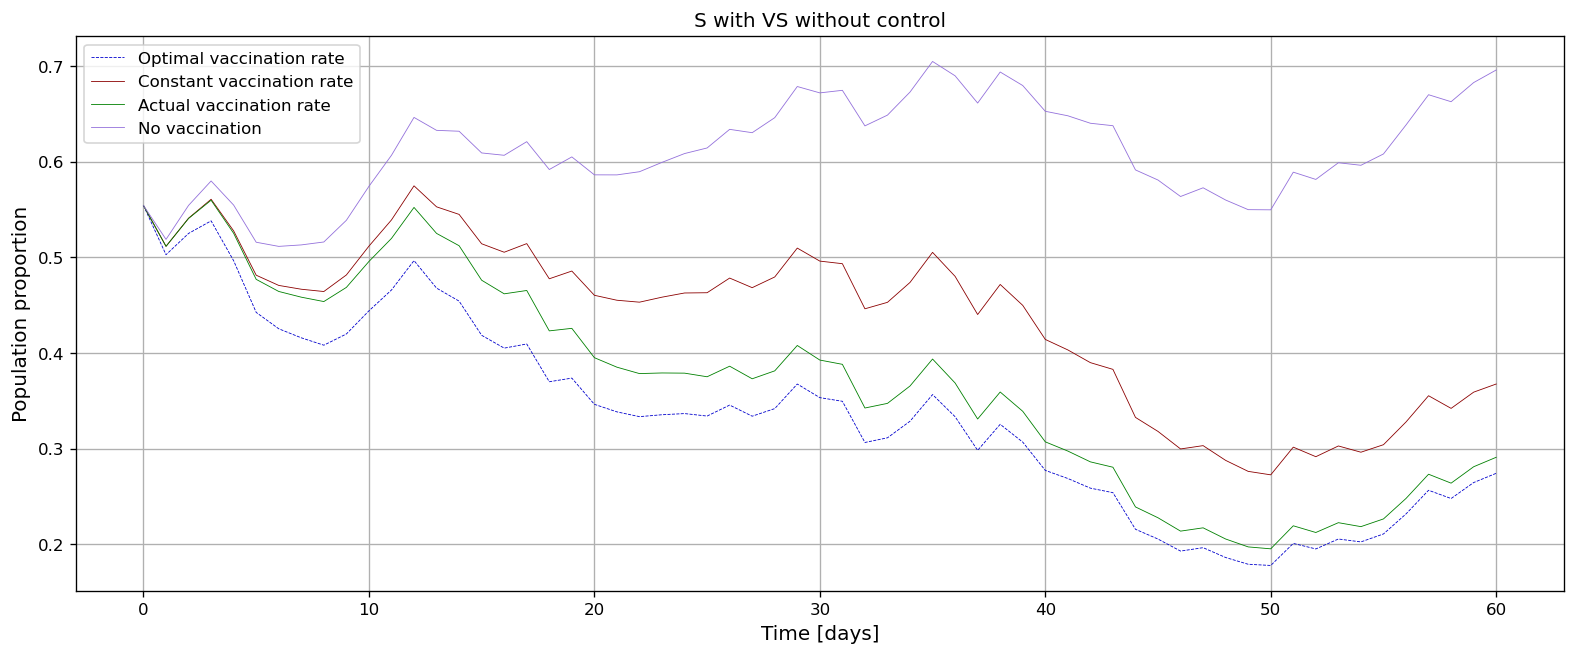

In [42]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, S/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, S_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, S_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, S_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('S with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('S_popn_change.png')

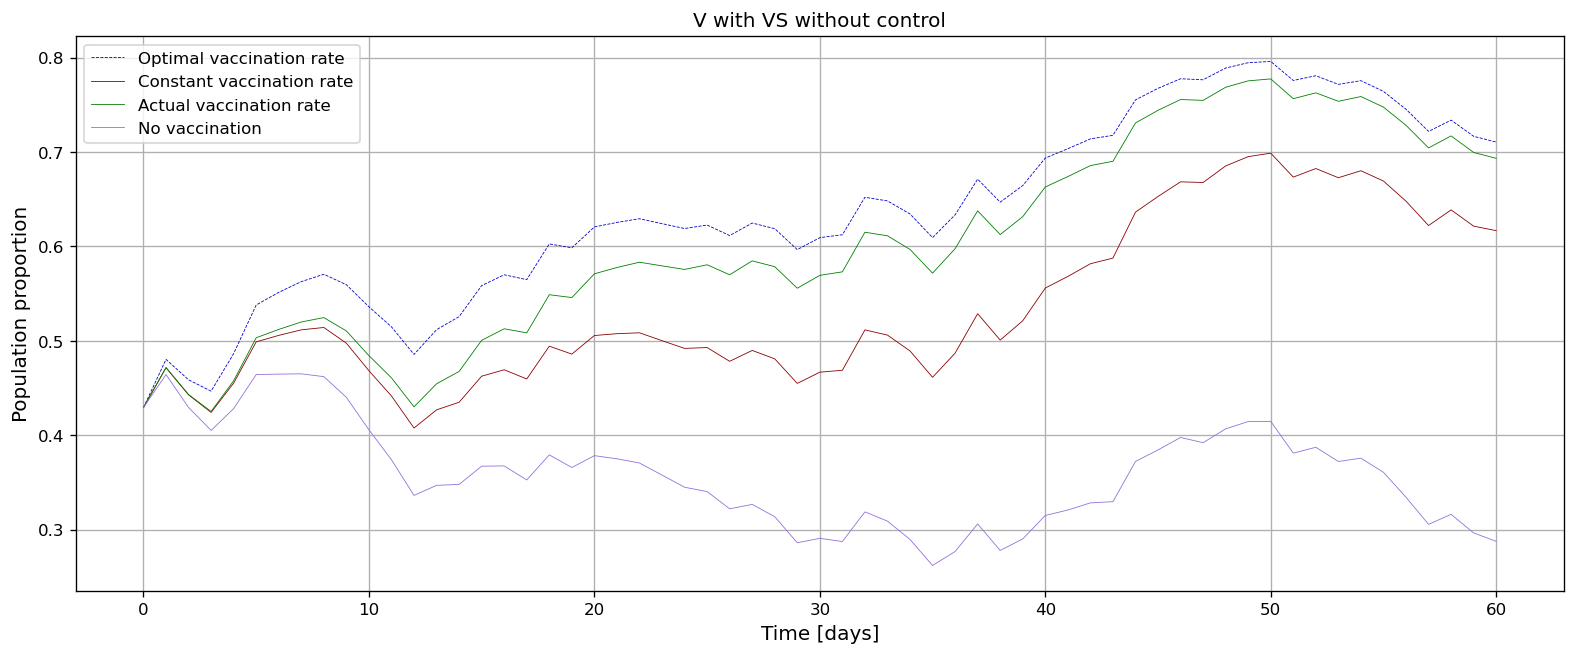

In [43]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, V/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, V_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, V_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, V_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('V with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('V_popn_change.png')

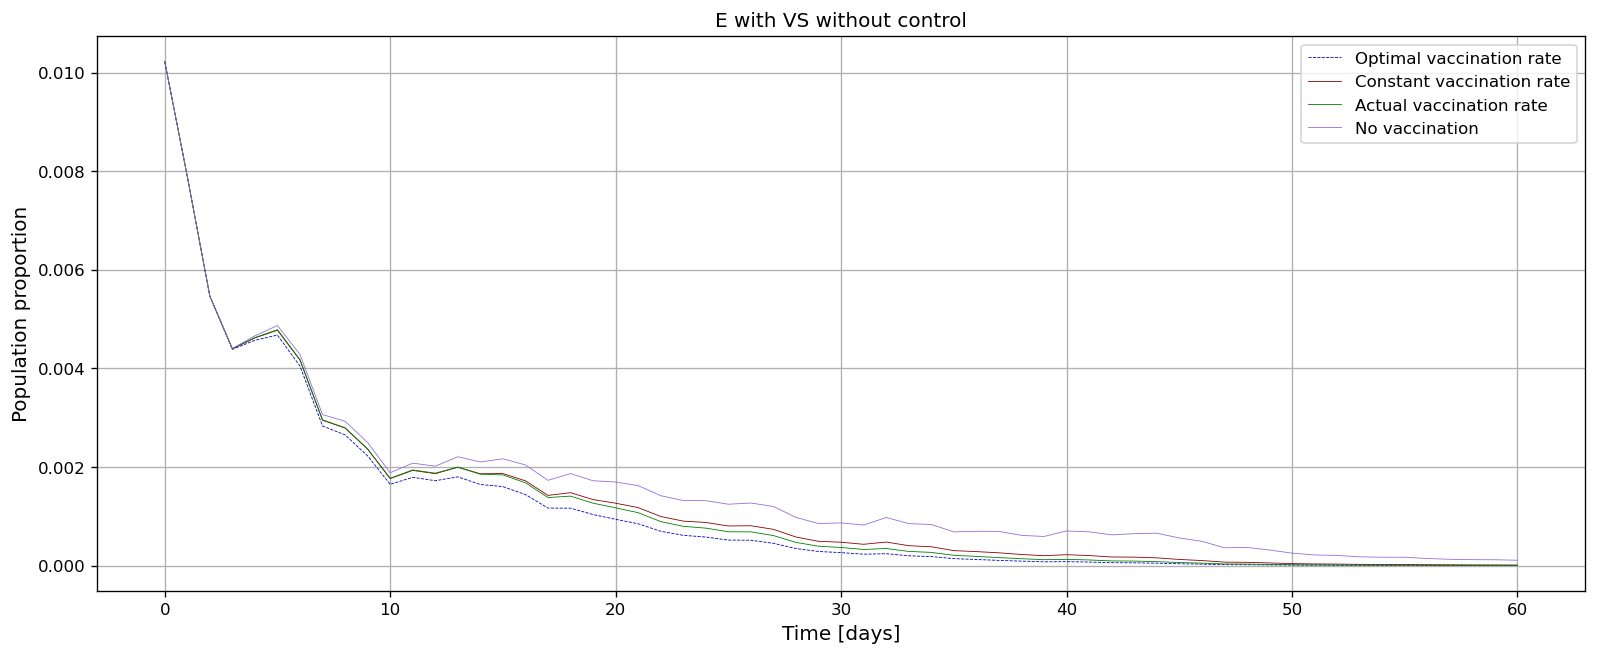

In [44]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, E/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, E_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, E_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, E_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('E with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('E_popn_change.png')

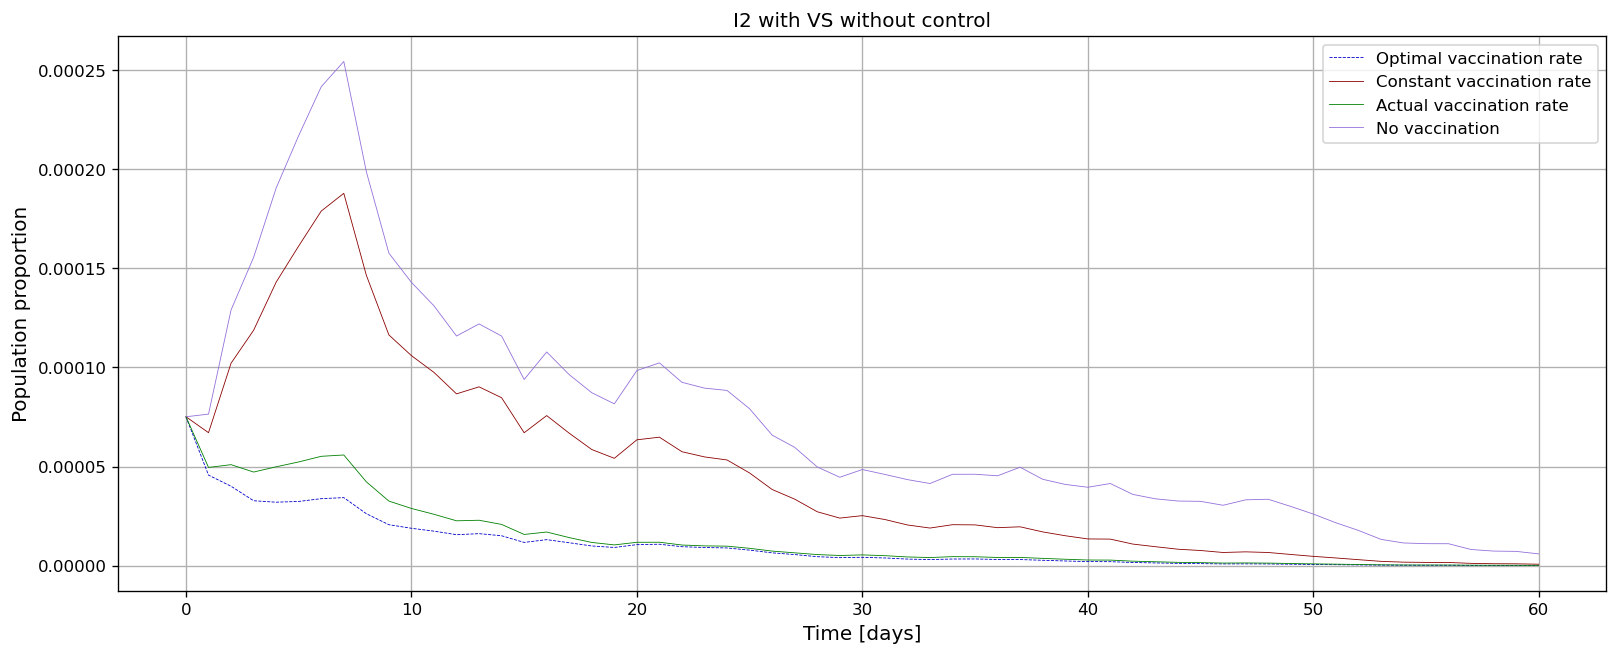

In [45]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, I2/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, I2_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, I2_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, I2_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('I2 with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('I2_popn_change.png')

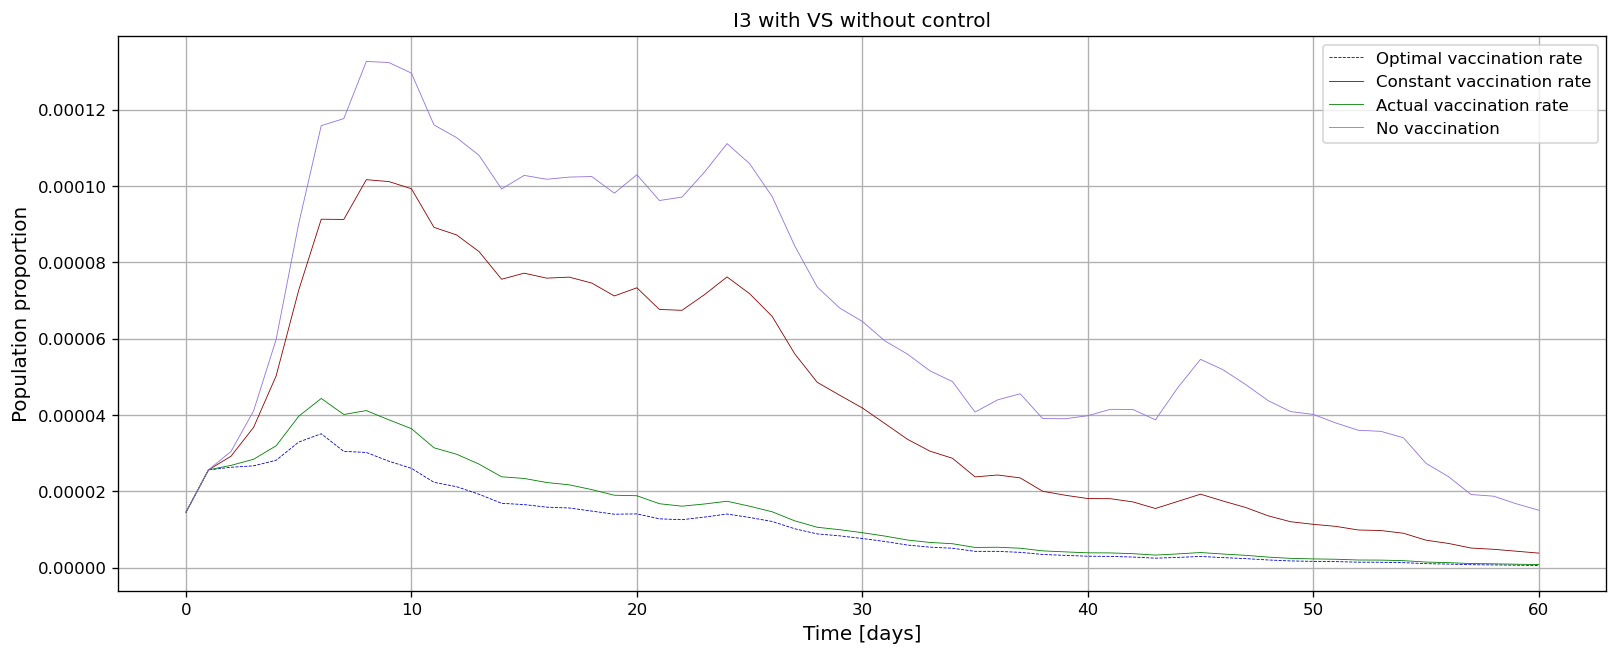

In [46]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, I3/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, I3_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, I3_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, I3_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('I3 with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('I3_popn_change.png')

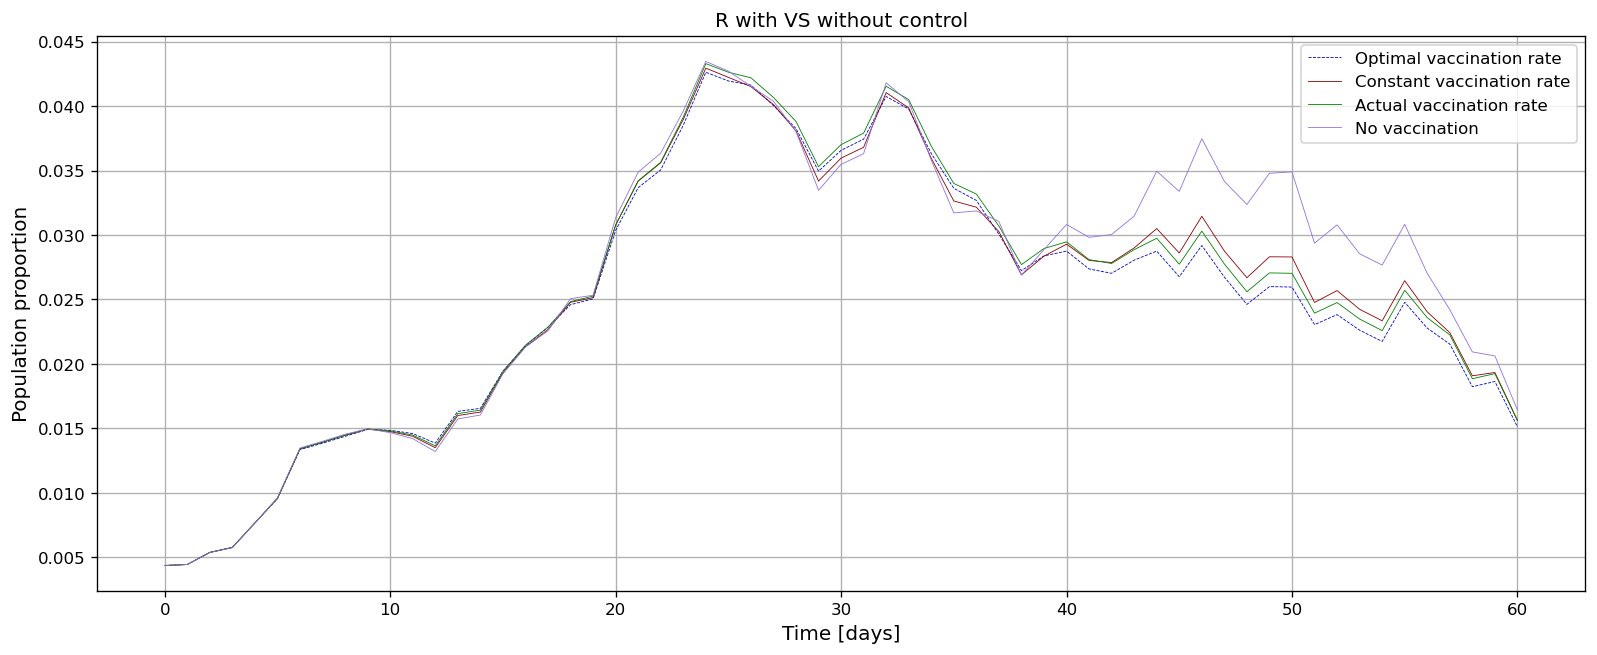

In [47]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, R/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, R_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, R_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, R_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('R with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('R_popn_change.png')

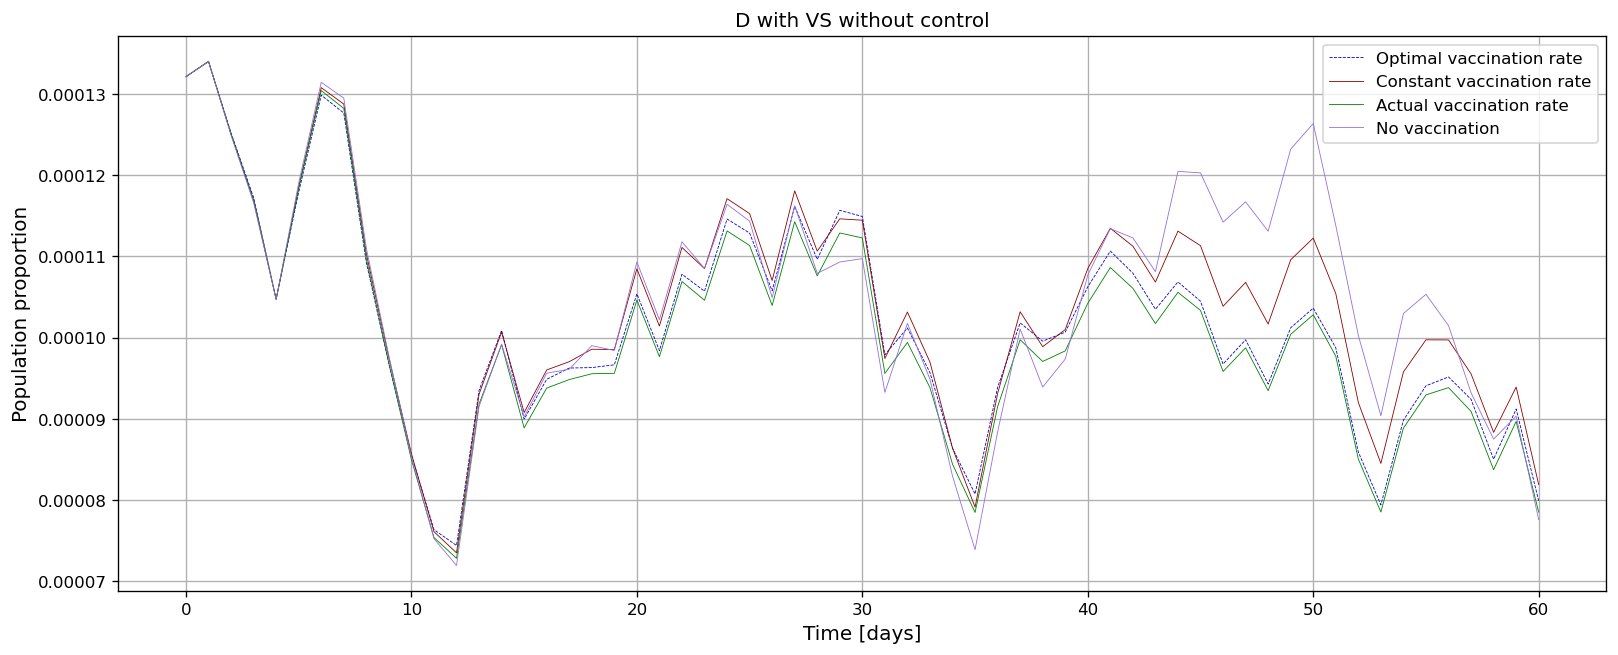

In [48]:
t = np.linspace(0, t_max, len(S))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, D/N_path_opt, lw = 0.5, ls = '--', color = 'mediumblue', label = 'Optimal vaccination rate')
ax0.plot(t, D_con/N_path_con, lw = 0.5, color = 'darkred', label = 'Constant vaccination rate')
ax0.plot(t, D_act/N_path_act, lw = 0.5, color = 'green', label = 'Actual vaccination rate')
ax0.plot(t, D_ori/N_path_ori, lw = 0.5, color = 'mediumpurple', label = 'No vaccination')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Population proportion', fontsize = 12)
ax0.set_title('D with VS without control', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('D_popn_change.png')

### Summary Table - Cost Analysis

In [49]:
summary_table= {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost', 'Total Cost'],
                'S0': [hosp_ori_cost, vacc_ori_cost+qua_ori_cost, econ_ori_cost, total_ori_cost],
                'no vacc': [format(hosp_ori_cost/total_ori_cost * 100, ".2f") + "%",
                                 format((vacc_ori_cost+qua_ori_cost)/total_ori_cost * 100, ".2f") + "%",
                                format(econ_ori_cost/total_ori_cost * 100, ".2f") + "%", "100%"],
                'S1': [hosp_constant_cost, vacc_constant_cost+qua_constant_cost, econ_constant_cost, total_constant_cost],
                'constant vacc': [format(hosp_constant_cost/total_constant_cost * 100, ".2f") + "%",
                                 format((vacc_constant_cost+qua_constant_cost)/total_constant_cost * 100, ".2f") + "%",
                                 format(econ_constant_cost/total_constant_cost * 100, ".2f") + "%", "100%"] ,
                'S2': [hosp_act_cost,vacc_act_cost+qua_act_cost,econ_act_cost, total_act_cost],
                'actual vacc': [format(hosp_act_cost/total_act_cost * 100, ".2f") + "%",
                                 format((vacc_act_cost+qua_act_cost)/total_act_cost * 100, ".2f") + "%",
                                 format(econ_act_cost/total_act_cost * 100, ".2f") + "%", "100%"],
                'S3-1': [hosp_opt_cost,vacc_opt_cost+qua_opt_cost,econ_opt_cost, total_opt_cost],
                'opt sigma0.1': [format(hosp_opt_cost/total_opt_cost * 100, ".2f") + "%",
                                 format((vacc_opt_cost+qua_opt_cost)/total_opt_cost * 100, ".2f") + "%",
                                 format(econ_opt_cost/total_opt_cost * 100, ".2f") + "%", "100%"],
               'S3-2': [hosp_cost_sigma_large,vacc_cost_sigma_large+qua_cost_sigma_large,econ_cost_sigma_large, total_cost_sigma_large],
                'opt sigma large': [format(hosp_cost_sigma_large/total_cost_sigma_large * 100, ".2f") + "%",
                                 format((vacc_cost_sigma_large+qua_cost_sigma_large)/total_cost_sigma_large * 100, ".2f") + "%",
                                 format(econ_cost_sigma_large/total_cost_sigma_large * 100, ".2f") + "%", "100%"],
               'S3-3': [hosp_cost_sigma_small,vacc_cost_sigma_small+qua_cost_sigma_small,econ_cost_sigma_small, total_cost_sigma_small],
                'opt sigma small': [format(hosp_cost_sigma_small/total_cost_sigma_small * 100, ".2f") + "%",
                                 format((vacc_cost_sigma_small+qua_cost_sigma_small)/total_cost_sigma_small * 100, ".2f") + "%",
                                 format(econ_cost_sigma_small/total_cost_sigma_small * 100, ".2f") + "%", "100%"],
                'S3-4': [hosp_cost_sigma_tiny, vacc_cost_sigma_tiny+qua_cost_sigma_tiny, econ_cost_sigma_tiny, total_cost_sigma_tiny],
                  'opt sigma tiny': [format(hosp_cost_sigma_tiny/total_cost_sigma_tiny * 100, ".2f") + "%",
                                 format((vacc_cost_sigma_tiny+qua_cost_sigma_tiny)/total_cost_sigma_tiny * 100, ".2f") + "%",
                                 format(econ_cost_sigma_tiny/total_cost_sigma_tiny * 100, ".2f") + "%", "100%"] 
               }

df_summary = pd.DataFrame(summary_table)
df_summary.set_index('Type', inplace=True)
print(df_summary)

                    S0 no vacc         S1 constant vacc         S2  \
Type                                                                 
Hosp Cost    12.170532  23.08%   8.839819        20.81%   6.155105   
Policy Cost   2.309103   4.38%   2.790411         6.57%   3.717584   
Econ Cost    38.260726  72.55%  30.847319        72.62%  29.340147   
Total Cost   52.740361    100%  42.477550          100%  39.212836   

            actual vacc       S3-1 opt sigma0.1       S3-2 opt sigma large  \
Type                                                                         
Hosp Cost        15.70%   5.455882       15.01%   6.298334          15.54%   
Policy Cost       9.48%   4.067879       11.19%   4.035550           9.96%   
Econ Cost        74.82%  26.836371       73.81%  30.195958          74.50%   
Total Cost         100%  36.360131         100%  40.529842            100%   

                  S3-3 opt sigma small       S3-4 opt sigma tiny  
Type                                       

## R0 Derivation

In [50]:
nominator_opt = (beta1 * gamma * (delta2 + p2 + death) * (delta3 + mu + death) + beta2 * p1 * gamma * (delta3 + mu + death) + beta3 * p1 * p2 * gamma)
denominator_opt = (gamma + death) * (delta1 + p1 + death) * (delta2 + p2 + death) * (delta3 + mu + death)

# optimal vaccination - two dose
extra_opt = birth*(death+repeated_u*sigma)/(death*(repeated_u+death))
R0_opt = nominator_opt/denominator_opt * extra_opt
print("R0 opt", R0_opt)


extra_sigma_small_opt = birth*(death+u_opt_sigma_small*sigma)/(death*(u_opt_sigma_small+death))
R0_sigma_small = nominator_opt/denominator_opt*extra_sigma_small_opt
#print("R0 sigma_small", R0_sigma_small)


alpha_constant = 0.0126 
np.repeat(alpha_constant, len(repeated_u))
extra_constant = birth*(death+np.repeat(alpha_constant, len(repeated_u))*sigma)/(death*(np.repeat(alpha_constant, len(repeated_u))+death))
R0_constant = nominator_opt/denominator_opt*extra_constant
print("R0 R0_constant", R0_constant)


extra_act = birth*(death+act_u*sigma)/(death*(act_u+death))
R0_act = nominator_opt/denominator_opt*extra_act
print("R0 act", R0_act)


extra_no = birth*(death+np.repeat(0, len(repeated_u))*sigma)/(death*(np.repeat(0, len(repeated_u))+death))
R0_no = nominator_opt/denominator_opt*extra_no
print("R0 no", R0_no)


R0 opt [0.09990514 0.09990514 0.09990514 0.09990514 0.09991133 0.09991133
 0.09991133 0.09991133 0.09991757 0.09992385 0.09992385 0.09993017
 0.09993654 0.09994942 0.09995594 0.09996911 0.09998248 0.10000291
 0.1000168  0.10003802 0.10006711 0.10008953 0.10012027 0.10015202
 0.10018483 0.10022742 0.10028099 0.10032783 0.10038689 0.10044929
 0.10052673 0.10059746 0.10068559 0.10076642 0.1008827  0.10099341
 0.10111361 0.10124458 0.10138782 0.1015689  0.10174504 0.10194055
 0.1021588  0.10240401 0.10272416 0.10309694 0.1035365  0.10406252
 0.10470332 0.10539082 0.10610708 0.10698154 0.10768035 0.10828197
 0.10872729 0.10896502 0.10921372 0.10921372 0.10921372 0.10947417]
R0 R0_constant [0.10197024 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024
 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024
 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024
 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024 0.10197024
 0.10197024 0.10197024 0.10197024 0.101

In [51]:
## R0 with booster 

In [52]:
# actual vaccination - with booster (60 days)
u_act_booster = np.array([   
    0.0126, 0.0132, 0.0141, 0.0151, 0.0158, 0.0166, 0.0174, 0.0179, 
    0.0190, 0.0198, 0.0203, 0.0208, 0.0219, 0.0230, 0.0239, 0.0250, 
    0.0261, 0.0269, 0.0285, 0.0275, 0.0275, 0.0272, 0.0267, 0.0262, 
    0.0256, 0.0249, 0.0245, 0.0217, 0.0216, 0.0214, 0.0210, 0.0202,
    0.0198, 0.0188, 0.0204, 0.0193, 0.0184, 0.0176, 0.0171, 0.0168,
    0.0163, 0.0158, 0.0152, 0.0145, 0.0136, 0.0133, 0.0129, 0.0133, 
    0.0128, 0.0125, 0.0123, 0.0124, 0.0122, 0.0124, 0.0115, 0.0112,
    0.0109, 0.0105, 0.0101, 0.0104])
extra_act_booster = birth*(death+u_act_booster*sigma)/(death*(u_act_booster+death))
R0_act_booster = nominator_opt/denominator_opt * extra_act_booster
print("R0 act_booster", R0_act_booster)

R0 act_booster [0.10197024 0.10179879 0.1015689  0.10134554 0.10120598 0.10106086
 0.10092906 0.10085266 0.1006987  0.10059746 0.10053823 0.10048184
 0.10036684 0.10026282 0.10018483 0.10009712 0.1000168  0.0999625
 0.09986304 0.09992385 0.09992385 0.09994296 0.09997577 0.10000983
 0.10005245 0.10010477 0.10013601 0.10038689 0.10039705 0.10041765
 0.10046004 0.10054984 0.10059746 0.10072536 0.10052673 0.10065976
 0.1007804  0.10089798 0.10097704 0.10102674 0.10111361 0.10120598
 0.10132482 0.10147587 0.10169287 0.10177171 0.10188253 0.10177171
 0.10191131 0.10200042 0.10206223 0.10203107 0.10209389 0.10203107
 0.10233091 0.10244154 0.10255823 0.10272416 0.1029032  0.10276763]


In [53]:
# actual vaccination - with booster extended (89 days)
u_act_booster_extend = np.array([   
    0.0126, 0.0132, 0.0141, 0.0151, 0.0158, 0.0166, 0.0174,
    0.0179, 0.0190, 0.0198, 0.0203, 0.0208, 0.0219, 0.0230, 
    0.0239, 0.0250, 0.0261, 0.0269, 0.0285, 0.0275, 0.0275,
    0.0272, 0.0267, 0.0262, 0.0256, 0.0249, 0.0245, 0.0217, 
    0.0216, 0.0214, 0.0210, 0.0202, 0.0198, 0.0188, 0.0204,
    0.0193, 0.0184, 0.0176, 0.0171, 0.0168, 0.0163, 0.0158, 
    0.0152, 0.0145, 0.0136, 0.0133, 0.0129, 0.0133, 0.0128,
    0.0125, 0.0123, 0.0124, 0.0122, 0.0124, 0.0115, 0.0112, 
    0.0109, 0.0105, 0.0101, 0.0104, 0.0106, 0.0106, 0.0108, 
    0.0111, 0.0113, 0.0117, 0.0123, 0.0127, 0.0132, 0.0139, 
    0.0144, 0.0149, 0.0155, 0.0165, 0.0175, 0.0183, 0.0193, 
    0.0201, 0.0208, 0.0214, 0.0230, 0.0242, 0.0252, 0.0263,
    0.0274, 0.0287, 0.0307, 0.0329, 0.0353])
extra_act_booster_extend = birth*(death+u_act_booster_extend*sigma)/(death*(u_act_booster_extend+death))
R0_act_booster_extend = nominator_opt/denominator_opt * extra_act_booster_extend
print("R0 act_booster_extend", R0_act_booster_extend)

R0 act_booster_extend [0.10197024 0.10179879 0.1015689  0.10134554 0.10120598 0.10106086
 0.10092906 0.10085266 0.1006987  0.10059746 0.10053823 0.10048184
 0.10036684 0.10026282 0.10018483 0.10009712 0.1000168  0.0999625
 0.09986304 0.09992385 0.09992385 0.09994296 0.09997577 0.10000983
 0.10005245 0.10010477 0.10013601 0.10038689 0.10039705 0.10041765
 0.10046004 0.10054984 0.10059746 0.10072536 0.10052673 0.10065976
 0.1007804  0.10089798 0.10097704 0.10102674 0.10111361 0.10120598
 0.10132482 0.10147587 0.10169287 0.10177171 0.10188253 0.10177171
 0.10191131 0.10200042 0.10206223 0.10203107 0.10209389 0.10203107
 0.10233091 0.10244154 0.10255823 0.10272416 0.1029032  0.10276763
 0.10268151 0.10268151 0.10259856 0.10247973 0.10240401 0.10226031
 0.10206223 0.10194055 0.10179879 0.10161742 0.10149864 0.10138782
 0.10126425 0.10107823 0.10091343 0.10079454 0.10065976 0.10056157
 0.10048184 0.10041765 0.10026282 0.10016012 0.100082   0.10000291
 0.09993017 0.09985138 0.09974319 0.09963

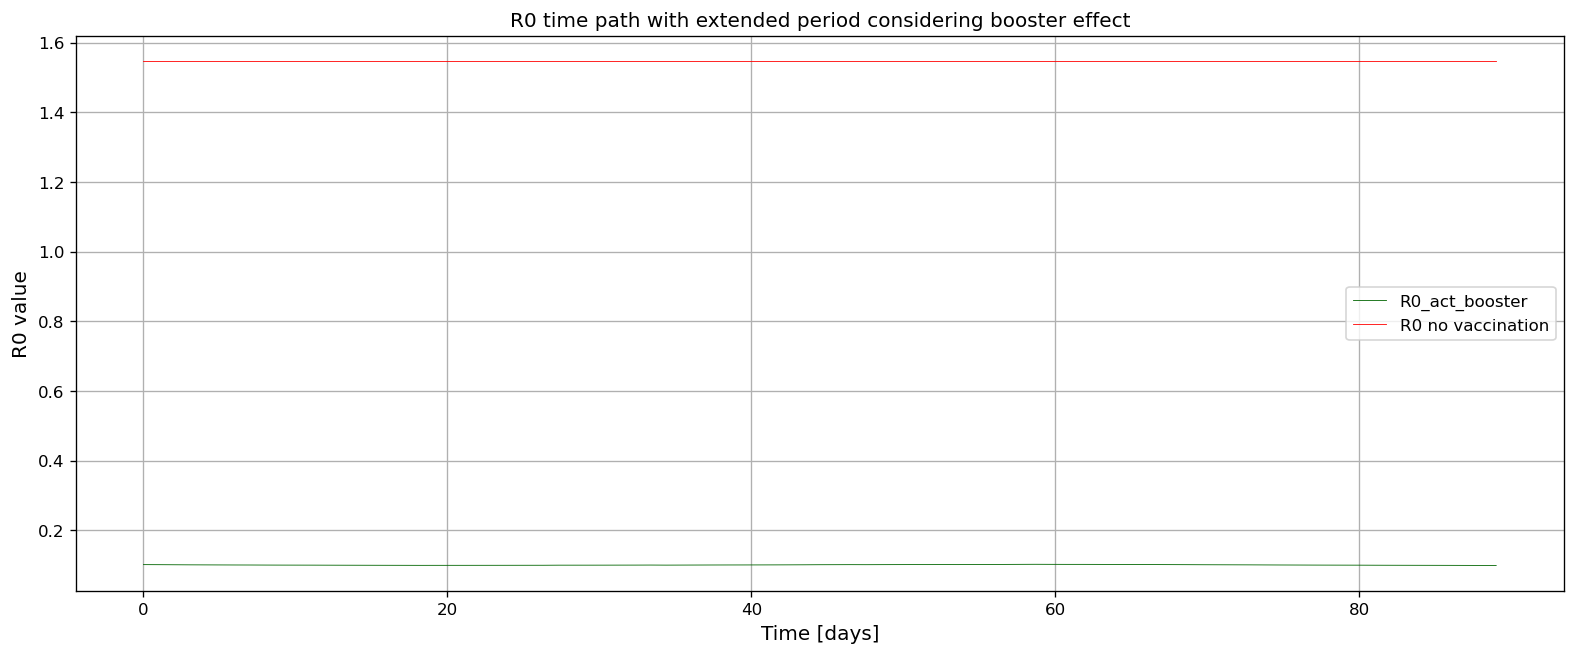

In [54]:
t = np.linspace(0, len(R0_act_booster_extend), len(R0_act_booster_extend))

fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, R0_act_booster_extend, lw = 0.5, color = 'darkgreen', label = 'R0_act_booster')
ax0.plot(t, np.repeat(R0_no[0],len(R0_act_booster_extend)), lw = 0.5, color = 'red', label = 'R0 no vaccination')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('R0 value', fontsize = 12)
ax0.set_title('R0 time path with extended period considering booster effect', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()


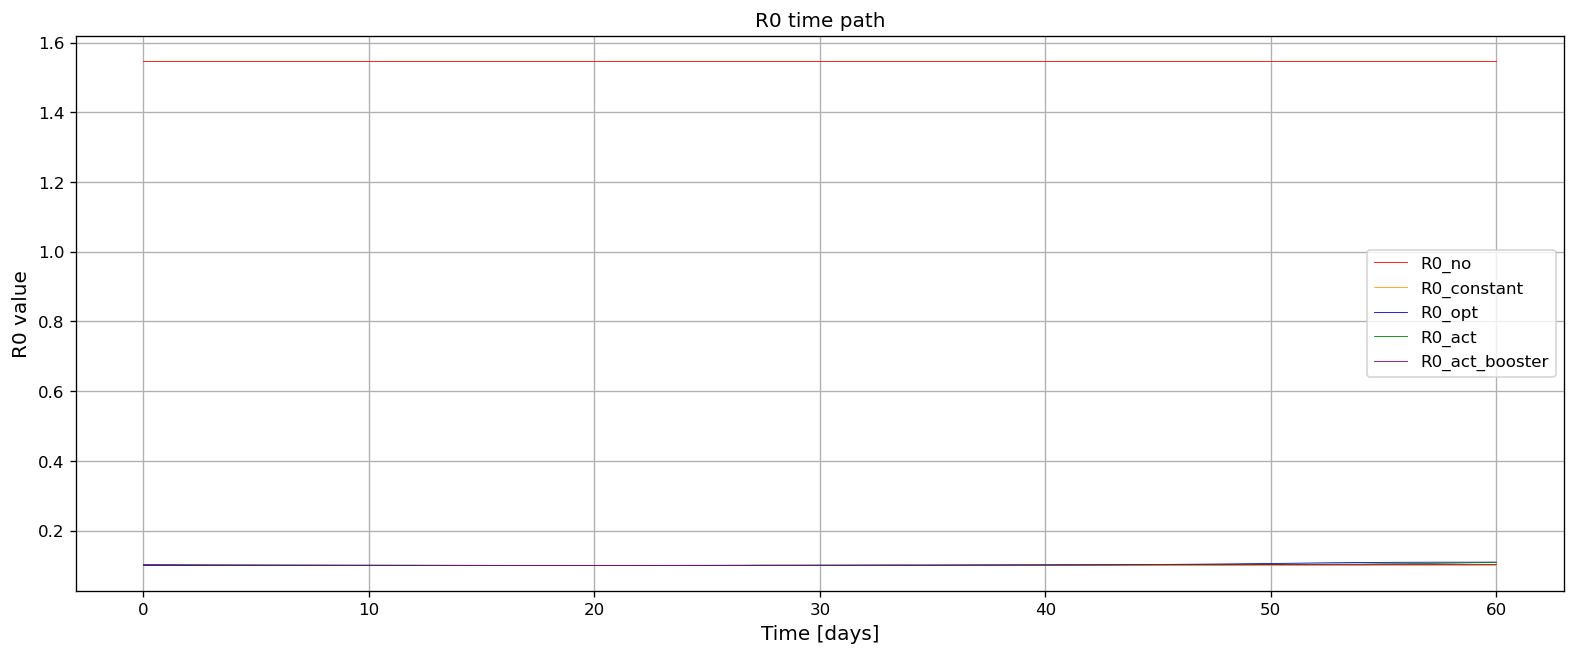

In [55]:
t = np.linspace(0, t_max, len(R0_opt))

fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)

ax0.plot(t, R0_no, lw = 0.5, color = 'red', label = 'R0_no')
ax0.plot(t, R0_constant, lw = 0.5, color = 'orange', label = 'R0_constant')
ax0.plot(t, R0_opt, lw = 0.5, color = 'mediumblue', label = 'R0_opt')
ax0.plot(t, R0_act, lw = 0.5, color = 'green', label = 'R0_act')
ax0.plot(t, R0_act_booster[0:60], lw = 0.5, color = 'purple', label = 'R0_act_booster')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('R0 value', fontsize = 12)
ax0.set_title('R0 time path', fontsize = 12)

ax0.legend()
ax0.grid()
#plt.show()
plt.savefig('R0 time path with booster.png')

In [56]:
summary_table_short= {'Type': ['Hosp Cost', 'Policy Cost', 'Econ Cost', 'Total Cost'],
                'no vacc': [hosp_ori_cost, vacc_ori_cost+qua_ori_cost, econ_ori_cost, total_ori_cost],
               
                'constant vacc': [hosp_constant_cost, vacc_constant_cost+qua_constant_cost, econ_constant_cost, total_constant_cost],
               
                'actual vacc': [hosp_act_cost,vacc_act_cost+qua_act_cost,econ_act_cost, total_act_cost],
                
                'standard': [hosp_opt_cost,vacc_opt_cost+qua_opt_cost,econ_opt_cost, total_opt_cost],
                
               'large noise': [hosp_cost_sigma_large,vacc_cost_sigma_large+qua_cost_sigma_large,econ_cost_sigma_large, total_cost_sigma_large],
               
               'small noise': [hosp_cost_sigma_small,vacc_cost_sigma_small+qua_cost_sigma_small,econ_cost_sigma_small, total_cost_sigma_small],
               
                'tiny noise': [hosp_cost_sigma_tiny, vacc_cost_sigma_tiny+qua_cost_sigma_tiny, econ_cost_sigma_tiny, total_cost_sigma_tiny],
            
               }

table_short = pd.DataFrame(summary_table_short)
table_short.set_index('Type', inplace=True)
print(table_short)

               no vacc  constant vacc  actual vacc   standard  large noise  \
Type                                                                         
Hosp Cost    12.170532       8.839819     6.155105   5.455882     6.298334   
Policy Cost   2.309103       2.790411     3.717584   4.067879     4.035550   
Econ Cost    38.260726      30.847319    29.340147  26.836371    30.195958   
Total Cost   52.740361      42.477550    39.212836  36.360131    40.529842   

             small noise  tiny noise  
Type                                  
Hosp Cost       4.793994    4.829627  
Policy Cost     3.554672    2.413340  
Econ Cost      23.178123   22.939450  
Total Cost     31.526789   30.182417  


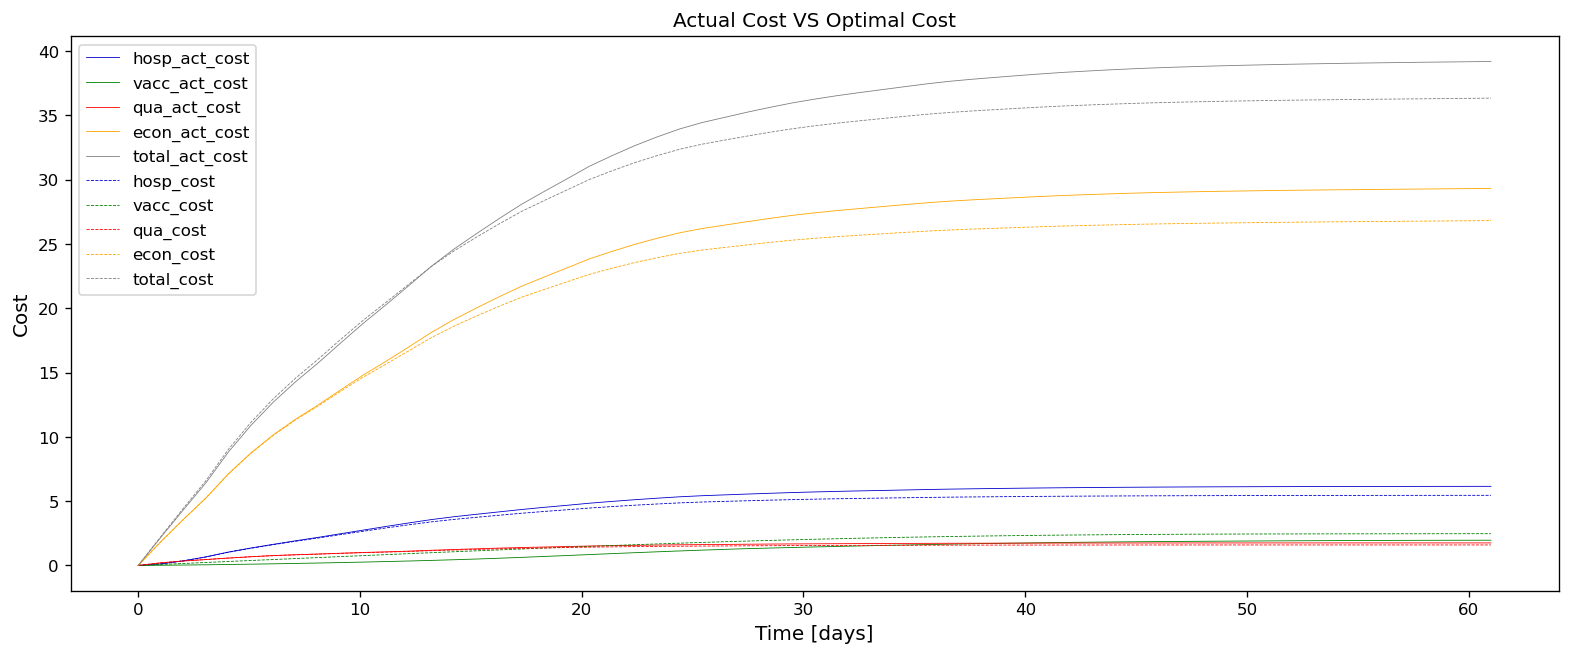

In [57]:
t = np.linspace(0, len(S_act), len(S_act))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_act_cost_partial, lw = 0.5, color = 'mediumblue', label = 'hosp_act_cost')
ax0.plot(t, vacc_act_cost_partial, lw = 0.5, color = 'green', label = 'vacc_act_cost')
ax0.plot(t, qua_act_cost_partial, lw = 0.5, color = 'red', label = 'qua_act_cost')
ax0.plot(t, econ_act_cost_partial, lw = 0.5, color = 'orange', label = 'econ_act_cost')
ax0.plot(t, total_act_cost_partial, lw = 0.5,  color = 'grey', label = 'total_act_cost')

ax0.plot(t, hosp_opt_cost_partial, lw = 0.5, ls = '--', color = 'mediumblue', label = 'hosp_cost')
ax0.plot(t, vacc_opt_cost_partial, lw = 0.5, ls = '--', color = 'green', label = 'vacc_cost')
ax0.plot(t, qua_opt_cost_partial, lw = 0.5, ls = '--', color = 'red', label = 'qua_cost')
ax0.plot(t, econ_opt_cost_partial, lw = 0.5, ls = '--', color = 'orange', label = 'econ_cost')
ax0.plot(t, total_opt_cost_partial, lw = 0.5, ls = '--', color = 'grey', label = 'total_cost')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Actual Cost VS Optimal Cost', fontsize = 12)
ax0.legend()

plt.savefig('Cost Component comparsion Actual Cost VS Optimal Cost.png')

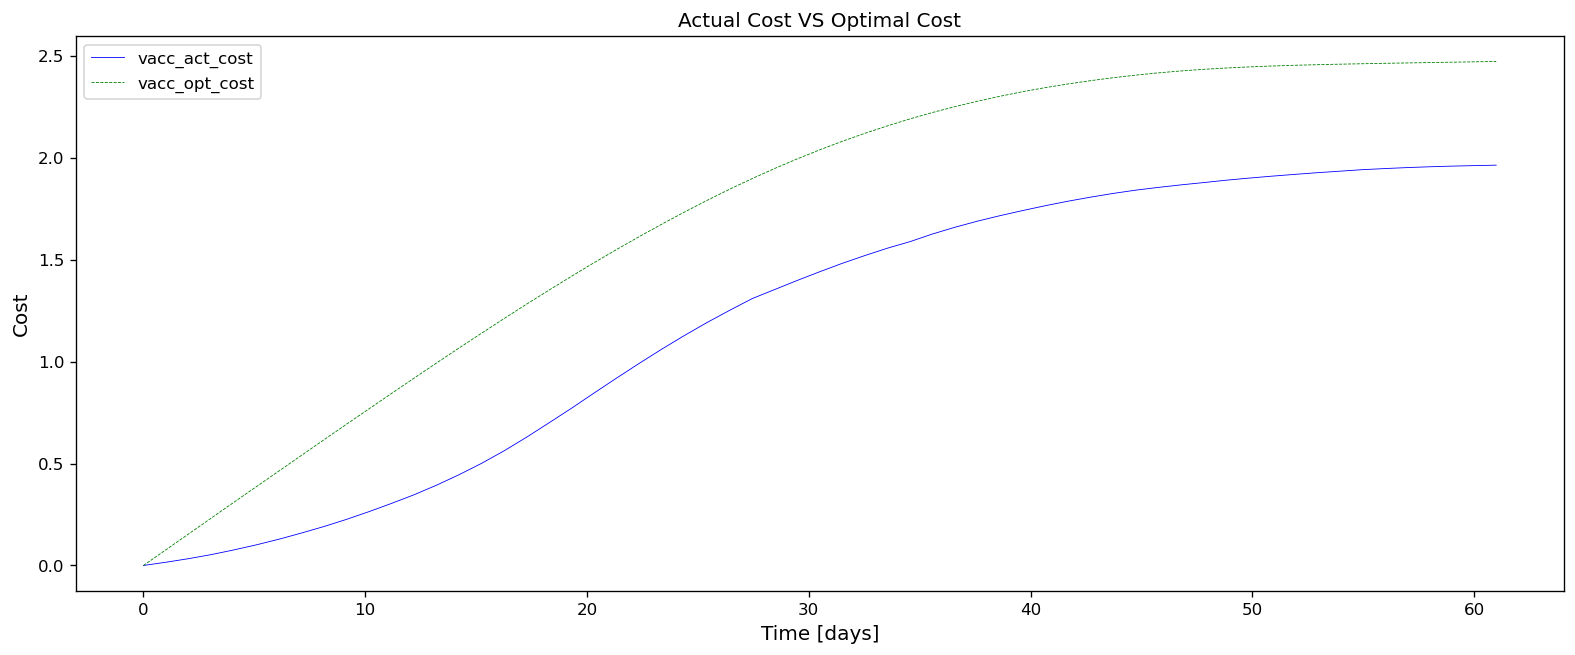

In [58]:
t = np.linspace(0, len(S_act), len(S_act))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
#ax0.plot(t, hosp_act_cost_partial, lw = 0.5, color = 'mediumblue', label = 'hosp_act_cost')
ax0.plot(t, vacc_act_cost_partial, lw = 0.5, color = 'blue', label = 'vacc_act_cost')
#ax0.plot(t, qua_act_cost_partial, lw = 0.5, color = 'red', label = 'qua_act_cost')
#ax0.plot(t, econ_act_cost_partial, lw = 0.5, color = 'orange', label = 'econ_act_cost')
#ax0.plot(t, total_act_cost_partial, lw = 0.5,  color = 'grey', label = 'total_act_cost')

#ax0.plot(t, hosp_opt_cost_partial, lw = 0.5, ls = '--', color = 'mediumblue', label = 'hosp_cost')
ax0.plot(t, vacc_opt_cost_partial, lw = 0.5, ls = '--', color = 'green', label = 'vacc_opt_cost')
#ax0.plot(t, qua_opt_cost_partial, lw = 0.5, ls = '--', color = 'red', label = 'qua_cost')
#ax0.plot(t, econ_opt_cost_partial, lw = 0.5, ls = '--', color = 'orange', label = 'econ_cost')
#ax0.plot(t, total_opt_cost_partial, lw = 0.5, ls = '--', color = 'grey', label = 'total_cost')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Actual Cost VS Optimal Cost', fontsize = 12)
ax0.legend()

plt.savefig('Cost Component comparsion Actual Cost VS Optimal Cost.png')

In [59]:
a = hosp_opt_cost_partial
a[1:] - a[:-1]

array([0.12085456, 0.23816519, 0.30364906, 0.36848162, 0.30903554,
       0.28024932, 0.26626852, 0.25355416, 0.26603254, 0.25831786,
       0.25628489, 0.24300408, 0.22643811, 0.19187712, 0.16340072,
       0.15856203, 0.1564263 , 0.1390879 , 0.12914205, 0.13509276,
       0.11404579, 0.10659814, 0.09521281, 0.08652992, 0.06724977,
       0.04985307, 0.04835892, 0.04565423, 0.04319256, 0.03579452,
       0.031399  , 0.02760189, 0.02463035, 0.02661949, 0.02463359,
       0.0214575 , 0.01713052, 0.01496145, 0.0143879 , 0.01354394,
       0.01150622, 0.0090065 , 0.00888297, 0.00731057, 0.00663549,
       0.00583121, 0.0053336 , 0.00460647, 0.00367768, 0.00322792,
       0.00275206, 0.00236142, 0.00216458, 0.00189717, 0.00166406,
       0.00133392, 0.00117631, 0.0009908 , 0.0009871 , 0.0009073 ])

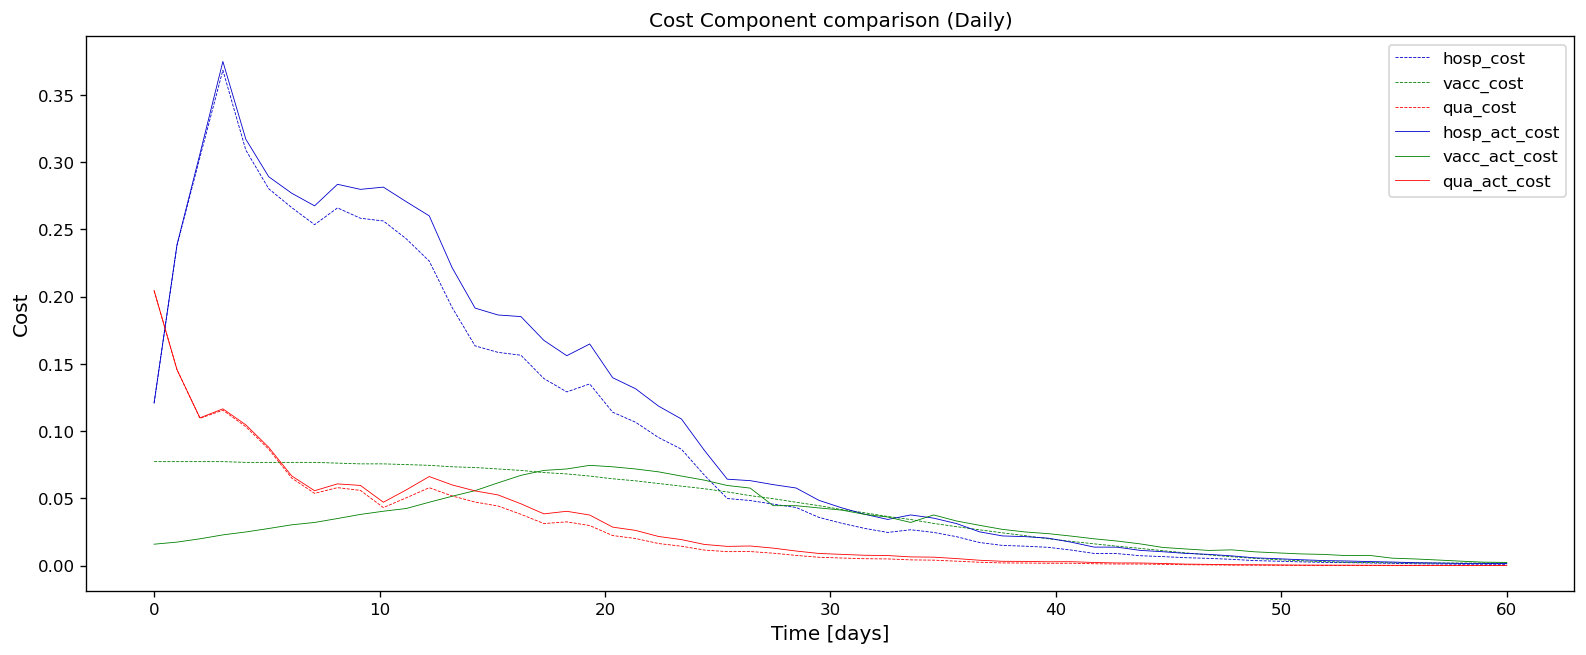

In [60]:
# Cost analysis: optimal vaccination - base case
hosp_opt_cost_daily = hosp_opt_cost_partial[1:] - hosp_opt_cost_partial[:-1]
vacc_opt_cost_daily = vacc_opt_cost_partial[1:] - vacc_opt_cost_partial[:-1]
qua_opt_cost_daily = qua_opt_cost_partial[1:] - qua_opt_cost_partial[:-1]
econ_opt_cost_daily =econ_opt_cost_partial[1:] - econ_opt_cost_partial[:-1]
total_opt_cost_daily =total_opt_cost_partial[1:] - total_opt_cost_partial[:-1]

hosp_act_cost_daily = hosp_act_cost_partial[1:] - hosp_act_cost_partial[:-1]
vacc_act_cost_daily = vacc_act_cost_partial[1:] - vacc_act_cost_partial[:-1]
qua_act_cost_daily = qua_act_cost_partial[1:] - qua_act_cost_partial[:-1]
econ_act_cost_daily =econ_act_cost_partial[1:] - econ_act_cost_partial[:-1]
total_act_cost_daily =total_act_cost_partial[1:] - total_act_cost_partial[:-1]

t = np.linspace(0, len(S_opt)-1, len(S_opt)-1)
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, hosp_opt_cost_daily, lw = 0.5, ls = '--', color = 'mediumblue', label = 'hosp_cost')
ax0.plot(t, vacc_opt_cost_daily, lw = 0.5, ls = '--', color = 'green', label = 'vacc_cost')
ax0.plot(t, qua_opt_cost_daily, lw = 0.5, ls = '--', color = 'red', label = 'qua_cost')
#ax0.plot(t, econ_opt_cost_daily, lw = 0.5, ls = '--', color = 'orange', label = 'econ_cost')
#ax0.plot(t, total_opt_cost_daily, lw = 0.5, ls = '--', color = 'grey', label = 'total_cost')

ax0.plot(t, hosp_act_cost_daily, lw = 0.5, color = 'mediumblue', label = 'hosp_act_cost')
ax0.plot(t, vacc_act_cost_daily, lw = 0.5, color = 'green', label = 'vacc_act_cost')
ax0.plot(t, qua_act_cost_daily, lw = 0.5, color = 'red', label = 'qua_act_cost')
#ax0.plot(t, econ_act_cost_daily, lw = 0.5,  color = 'orange', label = 'econ_act_cost')

ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Cost', fontsize = 12)
ax0.set_title('Cost Component comparison (Daily)', fontsize = 12)
ax0.legend()